# Dataset Curation 

some of our dft calculations could have gone wrong. The way to filter this is through the E-V curves for each sample. 
- input : non curated bs
- output: curated bs regarding ev curves

TODO: bopio and bopcal needed for featurizer ! separate package for bopfox ?

## check ev-curves for goodness

In [1]:
import sys
dataset = 'Fe-Mo'  #'Cr-Co-W'
atoms = dataset.split('-')
from Tools.DatasetTools.EVCurvesTools import *
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.Featurizer import Featurizer
import pickle
import os

In [2]:
import re

In [3]:
from scipy.optimize import curve_fit

In [4]:
from ase.eos import EquationOfState, birchmurnaghan

In [5]:
plt.rc('figure', figsize=(18, 8))
plt.rc('font', size=26)
plt.rc('xtick', labelsize=26)
plt.rc('ytick', labelsize=26)
plt.rc('axes', labelsize=30)
from matplotlib.lines import Line2D

In [6]:
make_plots = False

In [7]:
def get_key_for_curves(EVC: pd.core.series.Series, key='str') -> pd.core.series.Series:
    r2 = {}
    for index, data in EVC.items():
        r2[index]={}
        for params, curve in data.items():
            r2[index].update({params: curve[key]})
    return pd.Series(r2)
    

In [8]:
PBS = pd.read_pickle(os.path.join(dataset, 'ParsedBriefsummary.pkl'))

In [9]:
PBS.describe()

,nelem,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv
count,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000
mean,1.852201,12.773585,10.141509,22.915094,0.504702,0.495298
std,0.355460,10.545335,9.251248,13.374809,0.287006,0.287006
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000
25%,2.000000,5.000000,3.000000,13.000000,0.289187,0.266667
50%,2.000000,10.000000,8.000000,24.000000,0.500000,0.500000
75%,2.000000,17.000000,14.000000,30.000000,0.733333,0.710813
max,2.000000,53.000000,52.000000,53.000000,1.000000,1.000000


<AxesSubplot:ylabel='Frequency'>

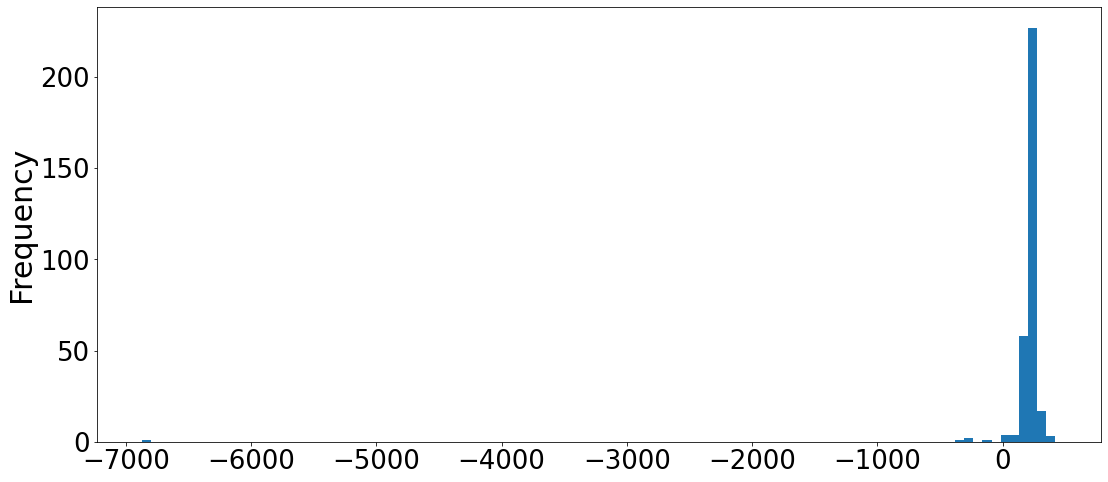

In [10]:
PBS.B0.plot.hist(bins=100)

## Investigate ev-curves

In [70]:
fittedcurvesloc = os.path.join(dataset, 'evcurvesfitted.json')
evcurvesloc = os.path.join(dataset,'evcurves.json' )
goodnessloc = os.path.join(dataset, 'goodness.json')
force = True#False

In [71]:
Mo_R = 'Mo_sv53.R.NM'

In [72]:
Fe_R = 'Fe_pv53.R.NM'

In [73]:
if not os.path.exists(fittedcurvesloc) or force:
    if not os.path.exists(evcurvesloc) or force:
        print('redoing')

        EV = Evcurves(Indexes = PBS.index, atoms=dataset.split(), dataset = dataset)#, search_str='**/volume_relaxed/**/volume-energy.dat')
        EV.load_evcurves( deltaks = PBS['deltak'], encuts = PBS['encut'])
        EVcurves = EV.evcurves
        EVcurves.to_json(evcurvesloc)
    else:
        EVcurves = pd.read_json(evcurvesloc, typ='series')
    goodness, fiteos, r2  = get_goodness(EVcurves, r2tol = 1e-6)
    if goodness.map(lambda g: False in g.values()).all():
        goodness = invert_goodness(goodness)
    Goodness = pd.Series(goodness)
    Fits = pd.Series(fiteos)
    R2 = pd.Series(r2)
    for index, data in EVcurves.items():
        for key, evcurve in data.items():
            if index in R2.keys():
                if key in R2[index].keys():
                    data[key].update({'r2': R2[index][key], 'fit': Fits[index][key], 'IsGood': Goodness[index][key]})
    EVcurves.to_json(fittedcurvesloc)
else:
    print('B')
    EVcurves = pd.read_json(fittedcurvesloc, typ='series')
    R2 = get_key_for_curves(EVcurves, 'r2')
    Goodness = get_key_for_curves(EVcurves, 'IsGood')
    Fits = get_key_for_curves(EVcurves, 'fit')

redoing


Fe_pv10Mo_sv20.sigma-ABBAB.NM, got paramas, selections = 3620: 100%|██████████| 318/318 [03:08<00:00,  1.69it/s]  
100%|██████████| 318/318 [00:00<00:00, 1105.93it/s]


In [74]:
EVcurves

Fe_pv8Mo_sv22.sigma-BBABB.FM     {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv10Mo_sv20.sigma-ABBAB.FM    {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv4Mo_sv20.C36-ABBBB.FM       {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv3Mo_sv10.mu-ABBBA.FM        {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv5Mo_sv24.chi-AABB.FM        {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
                                                       ...                        
Fe_pv3Mo_sv10.mu-ABBBA.NM        {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv8Mo_sv22.sigma-BBABB.NM     {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv1Mo_sv3.L12-AB3.FM          {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv8Mo_sv22.sigma-BBBBA.FM     {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv10Mo_sv20.sigma-ABBAB.NM    {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Length: 318, dtype: object

In [75]:
Febcc = 'Fe_pv1.bcc.FM'

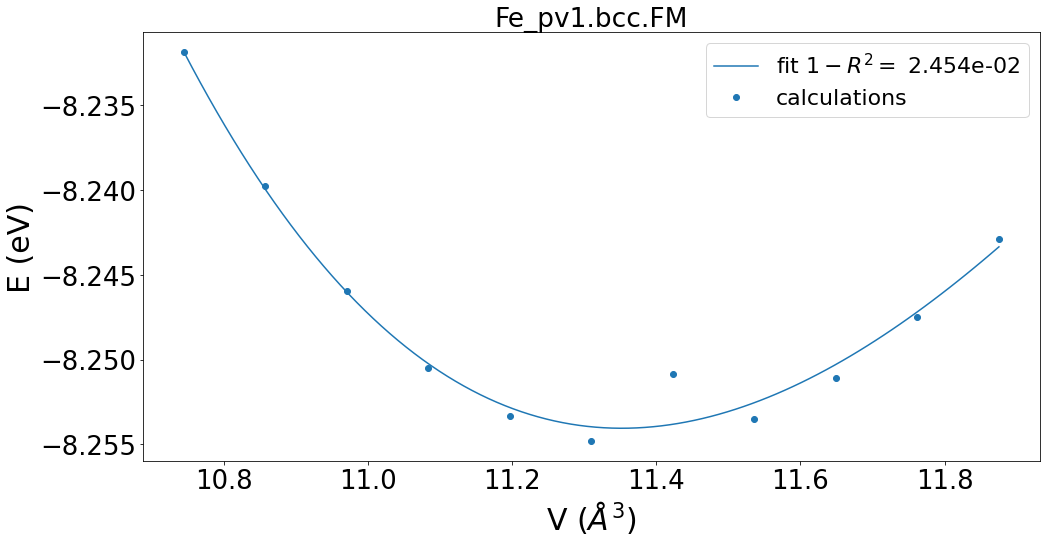

In [76]:
figs, axs = plot_curves(EVcurves[[Febcc]], Fits[[Febcc]], R2[[Febcc]])

In [77]:
EVcurves_df = pd.DataFrame.from_dict(EVcurves.to_dict(), orient='index')

In [78]:
EVcurves_df.index

Index(['Fe_pv8Mo_sv22.sigma-BBABB.FM', 'Fe_pv10Mo_sv20.sigma-ABBAB.FM',
       'Fe_pv4Mo_sv20.C36-ABBBB.FM', 'Fe_pv3Mo_sv10.mu-ABBBA.FM',
       'Fe_pv5Mo_sv24.chi-AABB.FM', 'Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM',
       'Fe_pv1Mo_sv3.D03-AB3.NM', 'Fe_pv6Mo_sv18.C36-BBBBA.NM',
       'Fe_pv6Mo_sv18.C36-BBBBA.FM', 'Fe_pv2Mo_sv11.mu-BBABB.NM',
       ...
       'Fe_pv30.sigma.FM', 'Fe_pv1.bcc.FM', 'Fe_pv2.bcc-cubic.FM',
       'Fe_pv6Mo_sv2.A15-AB.NM', 'Fe_pv16Mo_sv8.C36-ABBAA.NM',
       'Fe_pv4Mo_sv2.C15-A2B.FM', 'Fe_pv2Mo_sv4.C15-AB2.FM',
       'Fe_pv8Mo_sv16.C36-BAABB.NM', 'Fe_pv4Mo_sv9.mu-BBBAA.FM',
       'Fe_pv14Mo_sv16.sigma-AABBA.FM'],
      dtype='object', length=317)

In [79]:
R2_df = pd.DataFrame.from_dict(R2.to_dict(), orient='index')

In [80]:
Fits_df = pd.DataFrame.from_dict(Fits.to_dict(), orient='index')

In [81]:
Better_evcurves = {}

In [82]:
for index, evcurves in EVcurves_df.iterrows():
    nonan_evcurves = evcurves.dropna()
    if len(nonan_evcurves) > 1:
        break
    nonan_evcurves[nonan_evcurves.index][0]['calc_param'] = nonan_evcurves.index[0]
    Better_evcurves[index] = nonan_evcurves[nonan_evcurves.index][0]

In [83]:
Better_evcurves_df = pd.DataFrame.from_dict(Better_evcurves, orient='index')

In [84]:
ev_fit_results_df = pd.DataFrame.from_dict(Better_evcurves_df.ev_fit_results.to_dict(), orient='index')

In [85]:
fit_results = Better_evcurves_df.fit.map( lambda f : {name: val for name, val in zip(['E_murn', 'B_murn', 'Bdev_murn', 'V_murn'], f)})

In [86]:
fit_results_df = pd.DataFrame.from_dict(fit_results.to_dict(), orient='index')

In [87]:
if Febcc in fit_results_df.index:
    print(fit_results_df.loc[Febcc])
    print(f' Is Good : {Better_evcurves_df.loc[Febcc].IsGood}')
else:
    print(f'{Febcc} not in index')

E_murn        -8.254052
B_murn       173.620758
Bdev_murn     11.989819
V_murn        11.352096
Name: Fe_pv1.bcc.FM, dtype: float64
 Is Good : False


Text(0.5, 1.0, '63 Good Samples')

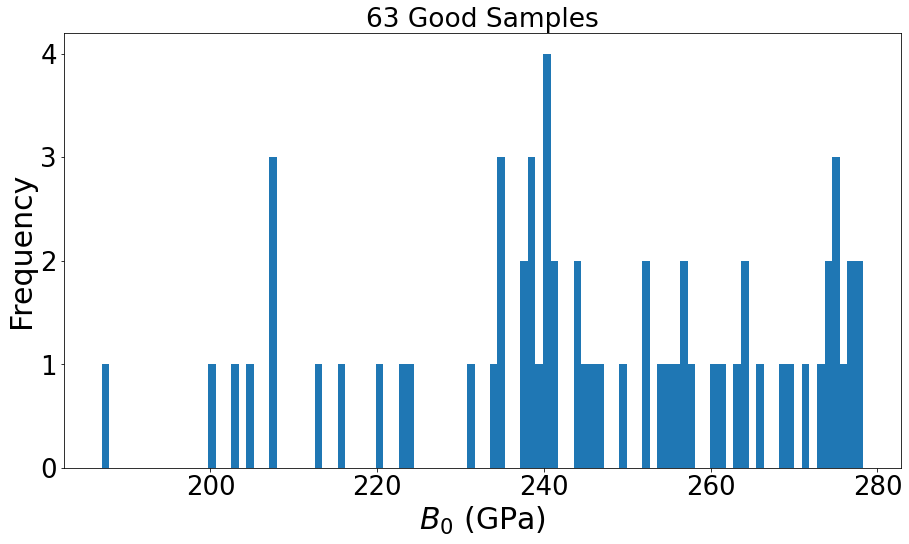

In [88]:
ax = fit_results_df[Better_evcurves_df.IsGood]['B_murn'].plot.hist(bins=100)
ax.set_xlabel(xlabel=r'$B_0$ (GPa)')
Ngood = Better_evcurves_df.IsGood.sum()
ax.set_title(f'{Ngood} Good Samples')

In [89]:
indexofgoodsamples = Better_evcurves_df.index[Better_evcurves_df.IsGood]

In [90]:
indexofbadsamples = Better_evcurves_df.index.difference(indexofgoodsamples) #[~Better_evcurves_df.IsGood]

In [91]:
Better_evcurves_df.index.difference(PBS.index)

Index([], dtype='object')

In [92]:
PBS.index.difference(Better_evcurves_df.index)

Index(['Fe_pv5Mo_sv8.mu-ABBAA.NM'], dtype='object')

In [93]:
indexofbadsamples

Index(['Fe_pv1.bcc.FM', 'Fe_pv1.bcc.NM', 'Fe_pv1.fcc.FM',
       'Fe_pv10Mo_sv14.C36-ABBAB.FM', 'Fe_pv10Mo_sv14.C36-ABBAB.NM',
       'Fe_pv10Mo_sv14.C36-ABBBA.FM', 'Fe_pv10Mo_sv14.C36-ABBBA.NM',
       'Fe_pv10Mo_sv14.C36-BABAB.FM', 'Fe_pv10Mo_sv14.C36-BABAB.NM',
       'Fe_pv10Mo_sv14.C36-BABBA.FM',
       ...
       'Mo_sv24.C36.FM', 'Mo_sv29.chi.FM', 'Mo_sv29.chi.NM',
       'Mo_sv30.sigma.FM', 'Mo_sv4.fcc-cubic.FM', 'Mo_sv4.fcc-cubic.NM',
       'Mo_sv6.C15.FM', 'Mo_sv6.C15.NM', 'Mo_sv8.A15.FM', 'Mo_sv8.A15.NM'],
      dtype='object', length=254)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


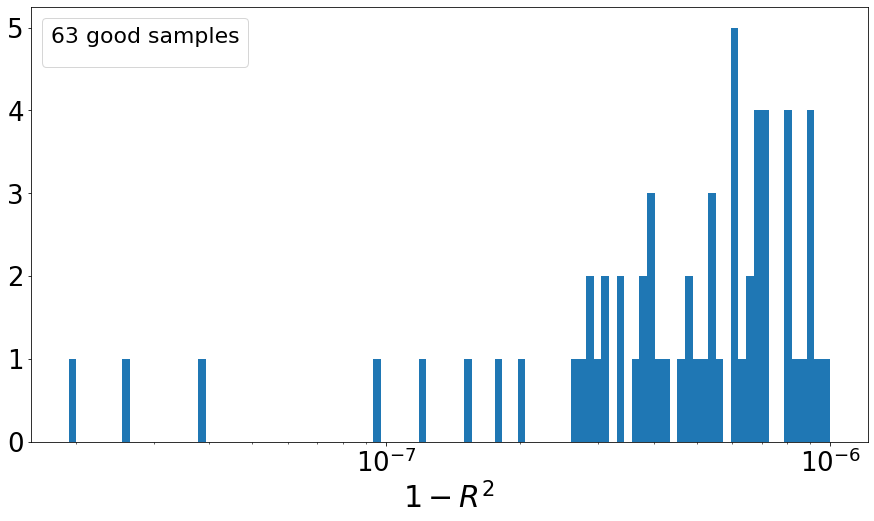

In [94]:
hist, bins = np.histogram(1-Better_evcurves_df.r2[indexofgoodsamples], bins=100)
logbins = np.logspace(np.log10(bins[0]), np.log10(bins[-1]), len(bins))
fig, ax = plt.subplots()
ax.hist(1-Better_evcurves_df.r2[indexofgoodsamples], bins=logbins)
Better_evcurves_df.r2[indexofgoodsamples]
ax.set_xscale('log')
xlabel = ax.set_xlabel('$1-R^2$')
NGOOD = len(indexofgoodsamples)
ax.legend(title=f'{NGOOD} good samples')

Text(0, 0.5, '$B_0$ from briefsummaries')

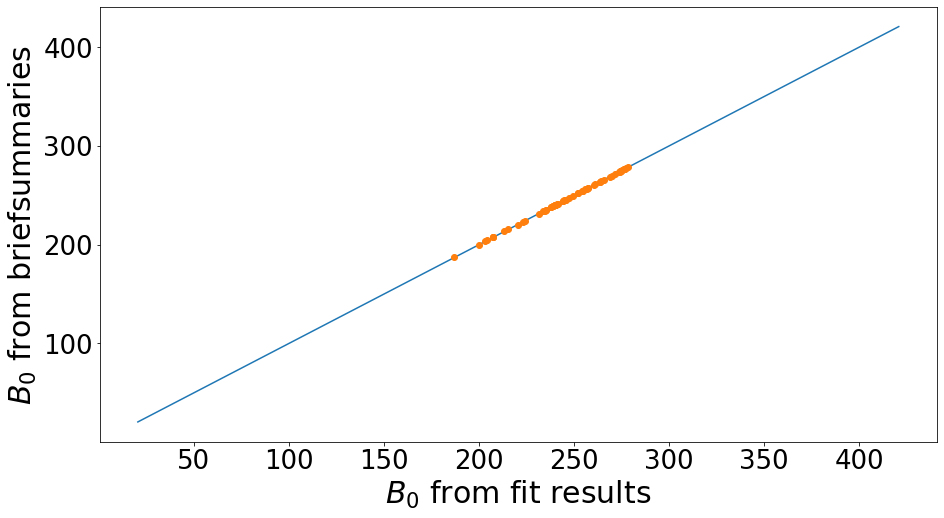

In [95]:
fig, ax = plt.subplots()
B0range = [PBS.B0[PBS.B0>0].min(), PBS.B0.max()]
ax.plot(B0range, B0range)
ax.plot(fit_results_df.B_murn[indexofgoodsamples], PBS.B0[indexofgoodsamples], 'o')
ax.set_xlabel(r'$B_0$ from fit results')
ax.set_ylabel(r'$B_0$ from briefsummaries')

# Differences between fits and available data for bad samples

In [96]:
( ( fit_results_df.B_murn[indexofbadsamples]==0 ) ).sum()

1

In [97]:
theweird = fit_results_df[fit_results_df.B_murn == 0].index

In [98]:
for params, curve in EVcurves[theweird].iloc[0].items():
    break

In [99]:
curve

{'evcurve': {'V': array([11.60335345, 11.54675172, 11.49015   , 11.43354828, 11.37694655,
         11.32034483, 11.2637431 , 11.20714138, 11.15053966, 11.09393793,
         11.03733621]),
  'E': array([-8.24017   , -8.23999552, -8.23966586, -8.23982414, -8.23985655,
         -8.23966483, -8.23926034, -8.23864103, -8.23780828, -8.23673207,
         -8.2354231 ])},
 'ev_fit_results': {'E_murn': -8.240007,
  'V_murn': 11.555812,
  'B_murn': 20.484025,
  'Bdev_murn': 59.173261},
 'r2': 0.0,
 'fit': [-8.238821974921631, 0, 0, 11.320344827586206],
 'IsGood': False,
 'calc_param': 'xc=PBE-PAW.E=450.dk=0.020'}

Text(0.5, 1.0, "Index(['Fe_pv28Mo_sv1.chi-BAAA.FM'], dtype='object')")

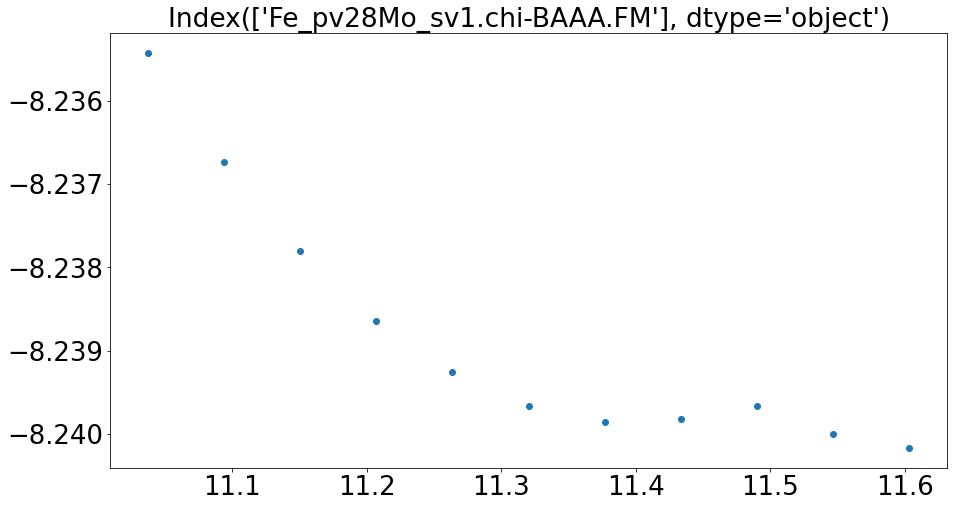

In [100]:
plt.scatter(curve['evcurve']['V'], curve['evcurve']['E'])
plt.title(theweird)

In [101]:
indexofbadsamples.difference(theweird)

Index(['Fe_pv1.bcc.FM', 'Fe_pv1.bcc.NM', 'Fe_pv1.fcc.FM',
       'Fe_pv10Mo_sv14.C36-ABBAB.FM', 'Fe_pv10Mo_sv14.C36-ABBAB.NM',
       'Fe_pv10Mo_sv14.C36-ABBBA.FM', 'Fe_pv10Mo_sv14.C36-ABBBA.NM',
       'Fe_pv10Mo_sv14.C36-BABAB.FM', 'Fe_pv10Mo_sv14.C36-BABAB.NM',
       'Fe_pv10Mo_sv14.C36-BABBA.FM',
       ...
       'Mo_sv24.C36.FM', 'Mo_sv29.chi.FM', 'Mo_sv29.chi.NM',
       'Mo_sv30.sigma.FM', 'Mo_sv4.fcc-cubic.FM', 'Mo_sv4.fcc-cubic.NM',
       'Mo_sv6.C15.FM', 'Mo_sv6.C15.NM', 'Mo_sv8.A15.FM', 'Mo_sv8.A15.NM'],
      dtype='object', length=253)

In [102]:
PBS.B0[indexofbadsamples.difference( theweird )]

Fe_pv1.bcc.FM                   170.72743
Fe_pv1.bcc.NM                  274.074843
Fe_pv1.fcc.FM                   -2.685409
Fe_pv10Mo_sv14.C36-ABBAB.FM    194.257707
Fe_pv10Mo_sv14.C36-ABBAB.NM    230.368542
                                  ...    
Mo_sv4.fcc-cubic.NM             241.05769
Mo_sv6.C15.FM                  235.215184
Mo_sv6.C15.NM                  234.041146
Mo_sv8.A15.FM                  253.594611
Mo_sv8.A15.NM                  253.234487
Name: B0, Length: 253, dtype: object

In [103]:
diff_fit_to_dataset = ((PBS.B0[indexofbadsamples.difference(theweird)] - fit_results_df.B_murn[indexofbadsamples.difference(theweird)])/fit_results_df.B_murn[indexofbadsamples.difference(theweird)]).abs().to_frame().rename(columns={0: 'B0'})

In [104]:
diff_fit_to_dataset['E0'] = ((PBS.E0[indexofbadsamples] - fit_results_df.E_murn[indexofbadsamples])/fit_results_df.E_murn[indexofbadsamples]).abs().dropna()

In [105]:
diff_fit_to_dataset['V0'] = ((PBS.V0[indexofbadsamples] - fit_results_df.V_murn[indexofbadsamples])/fit_results_df.V_murn[indexofbadsamples]).abs().dropna()

Text(0.5, 0, '$|(E_0 ^{fit} - E_0 ^{BS})/E_0^{BS}|$')

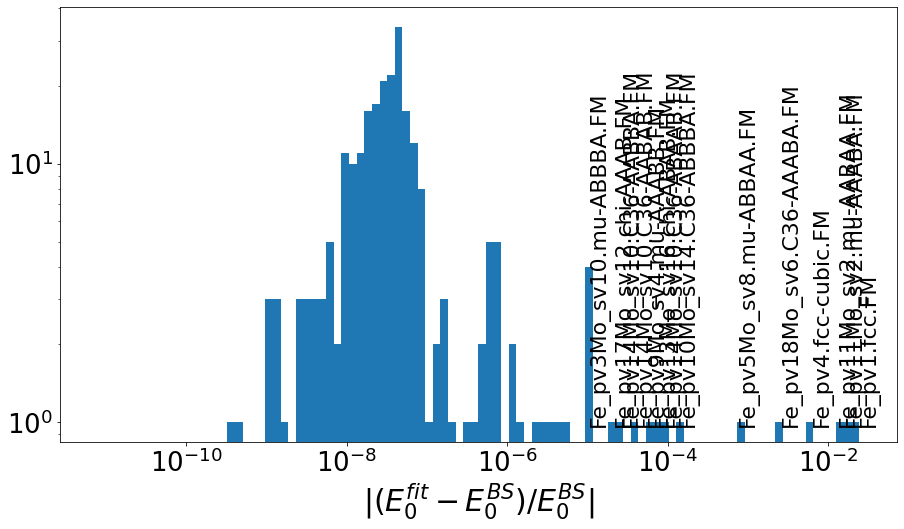

In [106]:
large_diff_E0 = diff_fit_to_dataset.query('E0 > 1e-5').index
fig, ax = plt.subplots()
hist, bins = np.histogram(diff_fit_to_dataset.E0, bins=100)
logbins = np.logspace(np.log10(bins[0]), np.log10(bins[-1]), len(bins))
loghist = plt.hist(diff_fit_to_dataset.E0, bins=logbins)
fig = plt.xscale('log')
fig = plt.yscale('log')
for index in large_diff_E0:
    x = diff_fit_to_dataset.E0[index]
    y = 1
    ax.annotate(index, (x, y), rotation='90')
plt.xlabel(r'$|(E_0 ^{fit} - E_0 ^{BS})/E_0^{BS}|$')

Text(0.5, 0, '$|(V_0 ^{fit} - V_0 ^{BS})/V_0^{BS}|$')

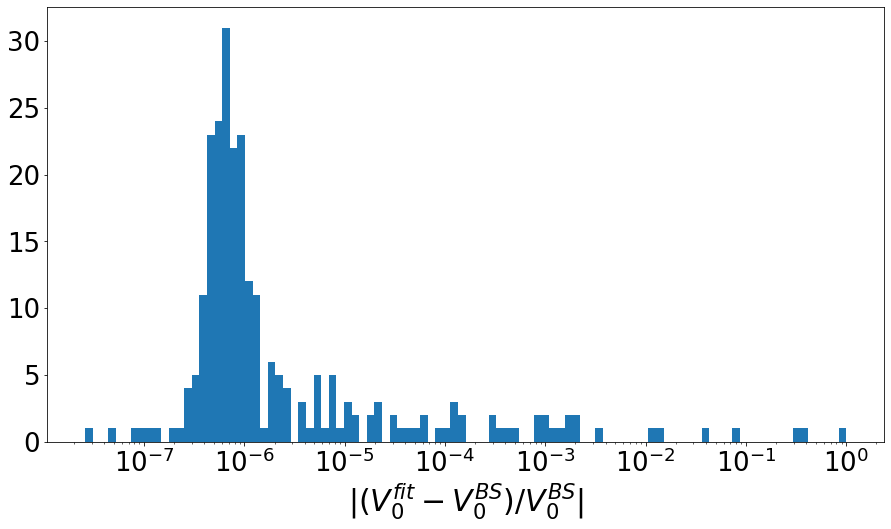

In [107]:
#large_diff_V0 = diff_fit_to_dataset.query('V0 > 0.2e-3').index
fig, ax = plt.subplots()
hist, bins = np.histogram(diff_fit_to_dataset.V0, bins=100)
logbins = np.logspace(np.log10(bins[0]), np.log10(bins[-1]), len(bins))
loghist = ax.hist(diff_fit_to_dataset.V0, bins=logbins)
#for index in large_diff_V0:
#    x = diff_fit_to_dataset.V0[index]
#    y = 1
#    ax.annotate(index, (x, y), rotation=90)
plt.xscale('log')
plt.xlabel(r'$|(V_0 ^{fit} - V_0 ^{BS})/V_0^{BS}|$')

Text(0.5, 0, '$|(B_0 ^{fit} - B_0 ^{BS})/B_0^{BS}|$')

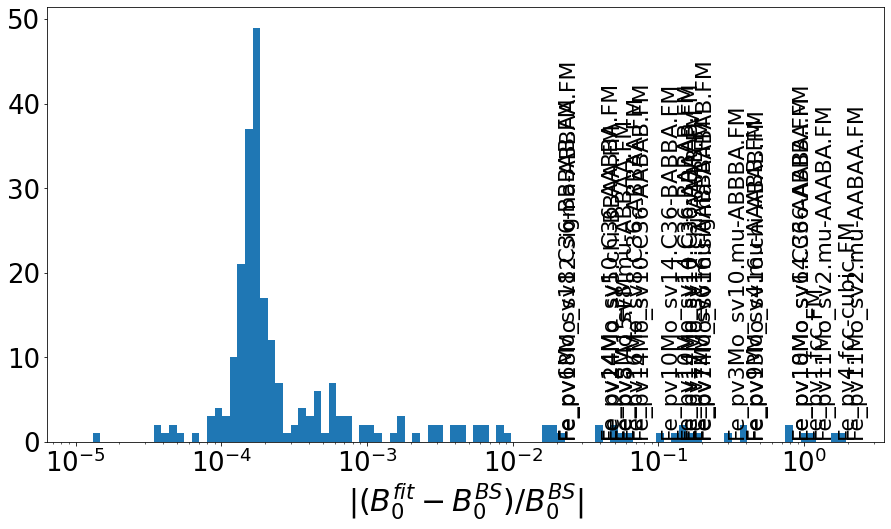

In [108]:
large_diff_B0 = diff_fit_to_dataset.query('B0 > 0.2e-1').index
fig, ax = plt.subplots()
hist, bins = np.histogram(diff_fit_to_dataset.B0, bins=100)
logbins = np.logspace(np.log10(bins[0]), np.log10(bins[-1]), len(bins))
loghist = plt.hist(diff_fit_to_dataset.B0, bins=logbins)
for index in large_diff_B0:
    x = diff_fit_to_dataset.B0[index]
    y = 1
    ax.annotate(index, (x, y), rotation=90)
plt.xscale('log')
plt.xlabel(r'$|(B_0 ^{fit} - B_0 ^{BS})/B_0^{BS}|$')

In [109]:
if make_plots:
    figs, axs = plot_curves(EVcurves[large_diff_B0], Fits[large_diff_B0], R2[large_diff_B0])
    for fig, ax  in zip(figs, axs):
        index = ax.title.get_text()
        V0, E0 = PBS[['V0','E0']].loc[index].values
        for paramspec, fitsparam in Fits[index].items():
            break
        e0 = fitsparam[0]
        v0 = fitsparam[-1]
    #    ax = ax.inset_axes([0.45, 0.3, 0.2, 0.2])
        ax.plot([V0], [E0], 'dk', label='value in briefsummary')
        ax.plot([v0],[e0], 'sb', label = 'value from fit')
        ax.legend()

# correct bad samples with new E0, B0, E0

# Test On obvious ones

In [110]:
Febcc = 'Fe_pv1.bcc.FM'

In [111]:
Better_evcurves_df.loc[Mo_R].IsGood

True

In [112]:
Better_evcurves_df.loc['Fe_pv1.bcc.FM'].IsGood

False

([<Figure size 1080x576 with 1 Axes>, <Figure size 1080x576 with 1 Axes>],
 [<AxesSubplot:title={'center':'Mo_sv53.R.NM'}, xlabel='V ($\\AA ^3$)', ylabel='E (eV)'>,
  <AxesSubplot:title={'center':'Fe_pv1.bcc.FM'}, xlabel='V ($\\AA ^3$)', ylabel='E (eV)'>])

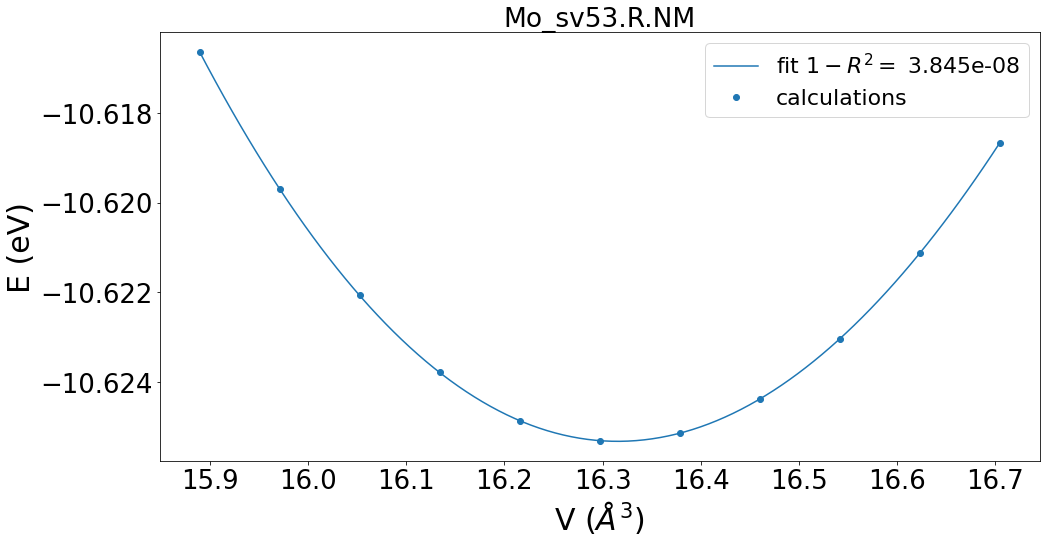

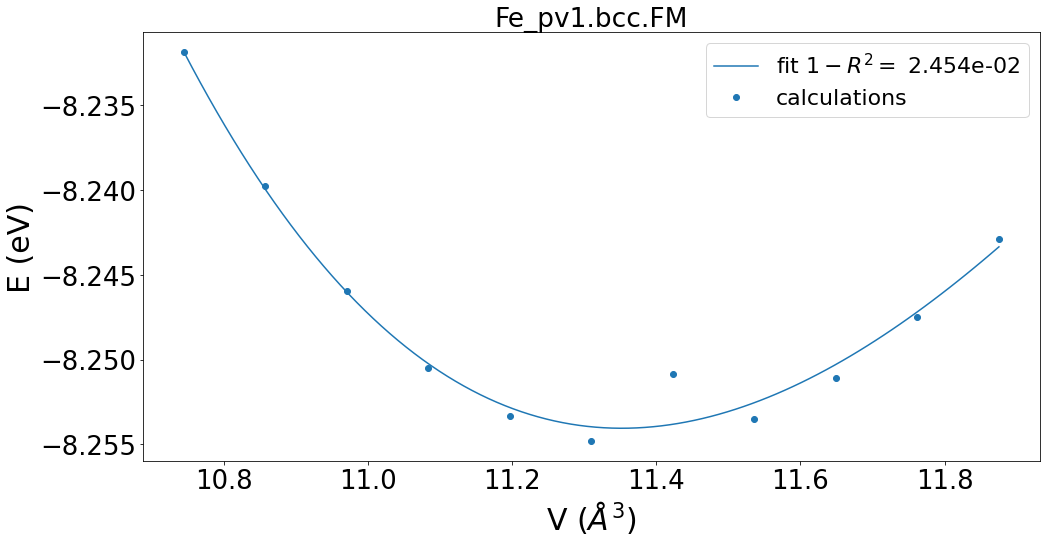

In [113]:
plot_curves(EVcurves[[Mo_R, Febcc]], Fits[[Mo_R, Febcc]], R2[[Mo_R, Febcc]])

In [114]:
GoodBS = PBS.loc[indexofgoodsamples]
GoodBS = GoodBS[~GoodBS.index.str.contains('sigma-BABBB.FM|sigma-AABBB.FM|mu-BBBBA.FM')]
BadBS = PBS.loc[indexofbadsamples]

# Try to correct the bad fits by removing points 

In [115]:
from importlib.machinery import SourceFileLoader

In [116]:
len(PBS)

318

In [117]:
len(indexofgoodsamples)

63

In [118]:
len(indexofbadsamples)

254

In [145]:
from importlib.machinery import SourceFileLoader
find_the_good_curve_inside = SourceFileLoader('find_the_good_curve_inside','Tools/DatasetTools/EVCurvesTools.py').load_module().find_the_good_curve_inside
is_common_sense_evcurve = SourceFileLoader('is_common_sense_evcurve','Tools/DatasetTools/EVCurvesTools.py').load_module().is_common_sense_evcurve
plot_the_sample = SourceFileLoader('plot_the_sample','Tools/DatasetTools/EVCurvesTools.py').load_module().plot_the_sample
plot_curves = SourceFileLoader('plot_curves','Tools/DatasetTools/EVCurvesTools.py').load_module().plot_curves
ev_per_angstrom3_to_GPA = 160.21

doexit = False

fixedevcurves = pd.Series([], name='FixedEVcurves')
fixedr2 = pd.Series([], name='FixedR2')
fixedfit = pd.Series([], name='Fixedfit')
tol = 1e-4
now_is_good = []
common_sense_evcurve = []
progress = tqdm(EVcurves[indexofbadsamples].items(), total = len(indexofbadsamples))
for index, paramcurve in progress:
    if index in fixedevcurves.keys():
        continue
    progress.set_description('index')
    if index in GoodBS.index:
        continue
    for paramspec, curvedata in paramcurve.items():
        r2, params_onreduced, reducedv, reducede = find_the_good_curve_inside(curvedata, tol=tol, reset_guess_params = True)
        common_sense_evcurve.append( is_common_sense_evcurve(reducedv, reducede, params_onreduced, unitsofb0='GPa'))
        now_is_good.append( (abs(r2-1) < tol) & common_sense_evcurve[-1] )
        progress.set_postfix_str(f'{index}, 1-r2 = {1-r2:.2e}, B0={params_onreduced[1]}, now is good = {now_is_good[-1]}')
        if params_onreduced[1] < 0 and now_is_good:
            raise ValueError('B0 is negative on '+index)
        fixedevcurves[index] = {
            paramspec: {
                'evcurve' :{ 'V' : reducedv , 'E': reducede },
                'ev_fit_results' :  {'E_murn': params_onreduced[0], 'V_murn' : params_onreduced[-1], 'B_murn': params_onreduced[1], 'Bdev_murn' : params_onreduced[2]},
                'r2' : r2,
                'IsGood' : now_is_good[-1],
                'fit': params_onreduced,
                'calc_param' : paramspec
            }
        }

index: 100%|██████████| 254/254 [00:14<00:00, 17.57it/s, Mo_sv8.A15.NM, 1-r2 = 1.36e-05, B0=253.27310208709832, now is good = True]                  


In [146]:
sum(now_is_good)

233

In [147]:
if make_plots:
    for index, fixedevcurve in fixedevcurves.items():
        if index not in large_diff_B0:
            continue
        #ax[0].plot(reducedv[bestcombi], reducede[bestcombi], 'o')
        for paramspec, data in fixedevcurve.items():
            isgood = data['IsGood']
            x =data['evcurve']['V']
            xx = np.linspace(x.min(), x.max(), 100)
            y = data['evcurve']['E']
            thisparams = copy.copy(data['fit'])
            thisparams[1]/=ev_per_angstrom3_to_GPA
            fixed_r2 = data['r2']
            B0 = thisparams[1]#data['fit'][1]
            V0 = thisparams[-1] # data['fit'][-1]
            message = f'fixed curve, $1-R^2$ = {1-fixed_r2:.1e}, $B_0 $= {B0*ev_per_angstrom3_to_GPA:.3f}, Isgood = {isgood}, v0 = {V0:.3f}'
        if not isgood :
            continue
            fig, ax = plot_curves(EVcurves[[index]], Fits[[index]],R2[[index]])
            l = ax[0].plot(xx, birchmurnaghan(xx, *thisparams), '--',label=message)[0]
            ax[0].plot(x, y, 'o', c=l.get_color())
            ax[0].legend()

In [148]:
fixedevcurves

Fe_pv1.bcc.FM                  {'xc=PBE-PAW.E=440.dk=0.016': {'evcurve': {'V'...
Fe_pv1.bcc.NM                  {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv1.fcc.FM                  {'xc=PBE-PAW.E=480.dk=0.020': {'evcurve': {'V'...
Fe_pv10Mo_sv14.C36-ABBAB.FM    {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv10Mo_sv14.C36-ABBAB.NM    {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
                                                     ...                        
Mo_sv4.fcc-cubic.NM            {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Mo_sv6.C15.FM                  {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Mo_sv6.C15.NM                  {'xc=PBE-PAW.E=400.dk=0.014': {'evcurve': {'V'...
Mo_sv8.A15.FM                  {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Mo_sv8.A15.NM                  {'xc=PBE-PAW.E=400.dk=0.016': {'evcurve': {'V'...
Name: FixedEVcurves, Length: 254, dtype: object

## check new total of good curves

In [149]:
fixedevcurves_df = pd.DataFrame.from_dict(fixedevcurves.to_dict(), orient='index')

In [150]:
fixedevcurves_df.shape

(254, 14)

In [151]:
Better_fixedevcurves = {}

In [152]:
for index, evcurves in fixedevcurves_df.iterrows():
    nonan_evcurves = evcurves.dropna()
    if len(nonan_evcurves) > 1:
        break
    nonan_evcurves[nonan_evcurves.index][0]['calc_param'] = nonan_evcurves.index[0]
    Better_fixedevcurves[index] = nonan_evcurves[nonan_evcurves.index][0]

In [153]:
Better_fixedevcurves_df = pd.DataFrame.from_dict(Better_fixedevcurves, orient='index')

In [154]:
fixedR2 = pd.Series([])
for index, curve in fixedevcurves.items():
    for paramspec, curvedata in curve.items():
        fixedR2[index] = {paramspec: curvedata['r2']}

In [155]:
fixedFits = pd.Series([])
for index, curve in fixedevcurves.items():
    for paramspec, curvedata in curve.items():
        fixedFits[index] = {paramspec: curvedata['fit']}

In [156]:
fixed_ev_fit_results = {} #pd.DataFrame([])
for index, curve in fixedevcurves.items():
    for paramspec, curvedata in curve.items():
        fixed_ev_fit_results[index] = pd.Series(curvedata['ev_fit_results'])
fixed_ev_fit_results_df = pd.DataFrame.from_dict(fixed_ev_fit_results, orient='index')

In [157]:
indexoffixedgoodsamples = Better_fixedevcurves_df.query('IsGood == True').index

In [158]:
len(indexoffixedgoodsamples)

233

In [159]:
indexoffixedbadsamples = Better_fixedevcurves_df.index.difference(indexoffixedgoodsamples)

In [160]:
len(indexoffixedbadsamples)

21

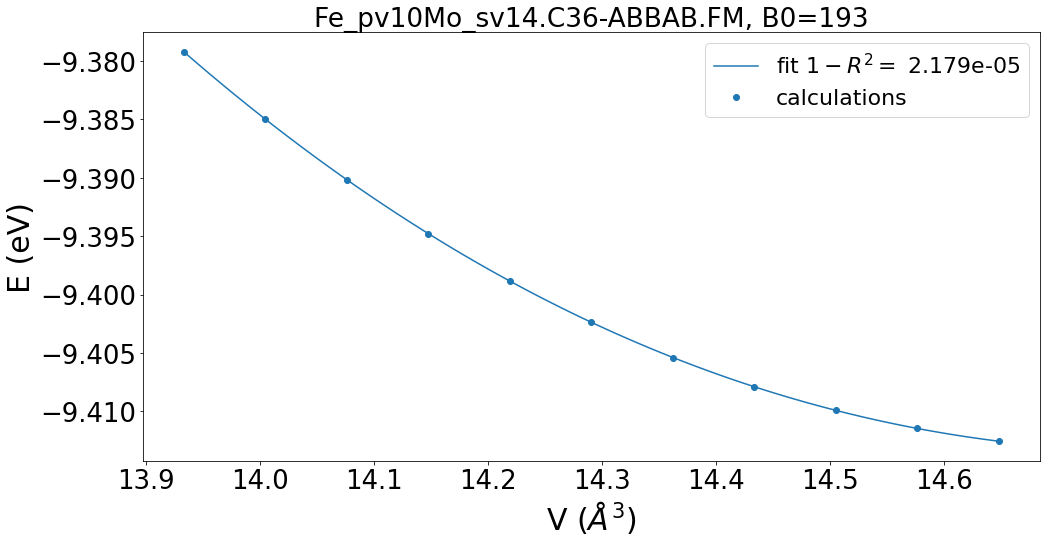

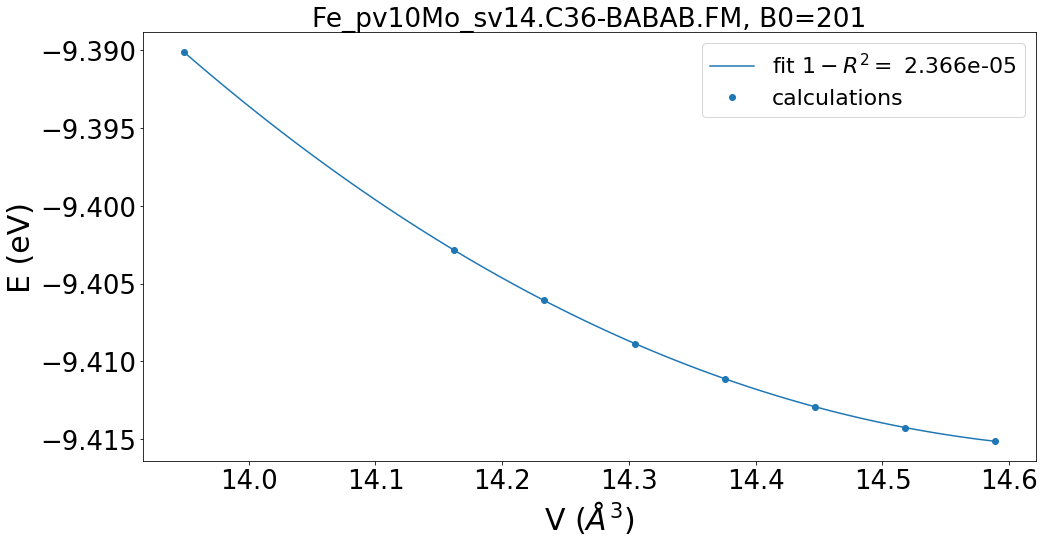

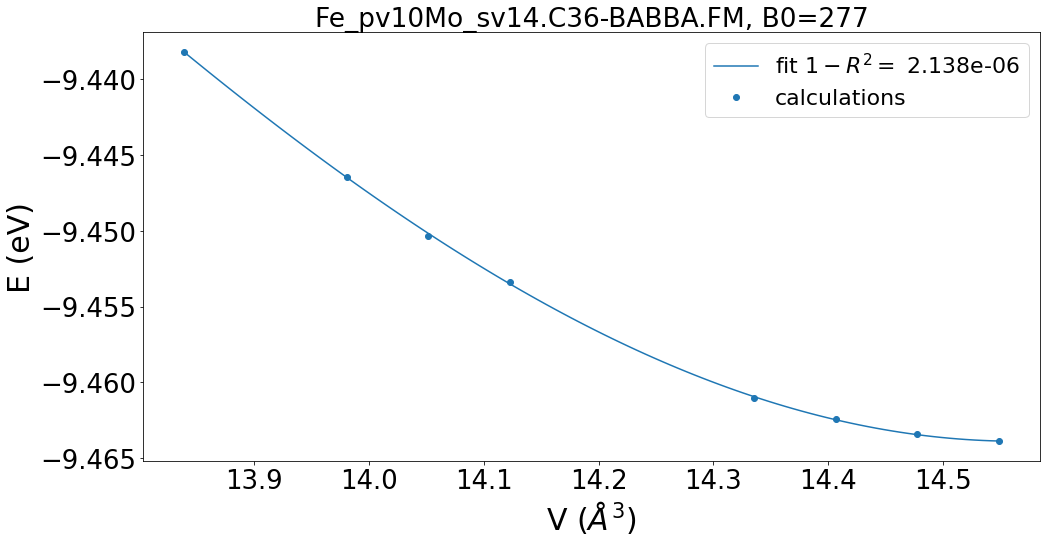

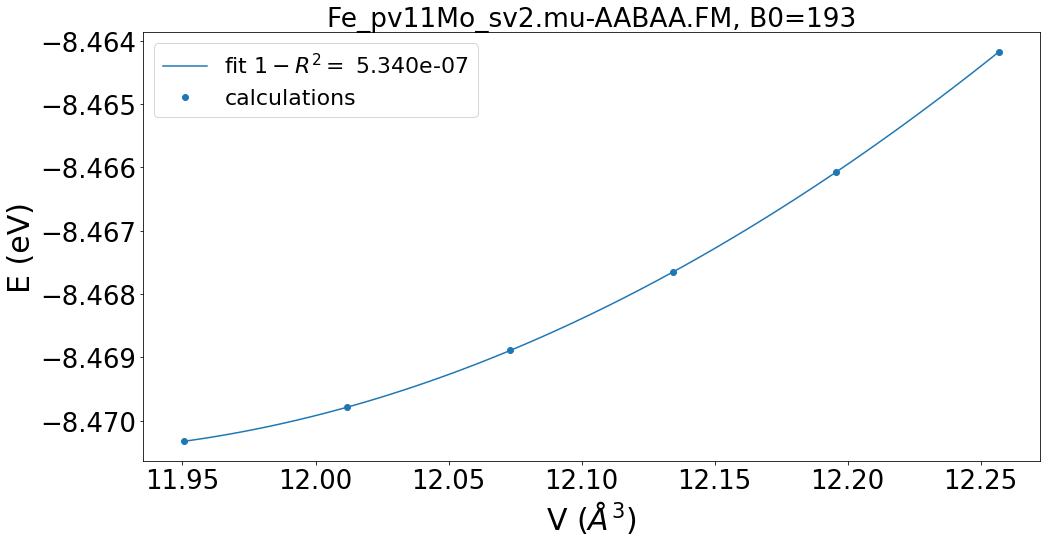

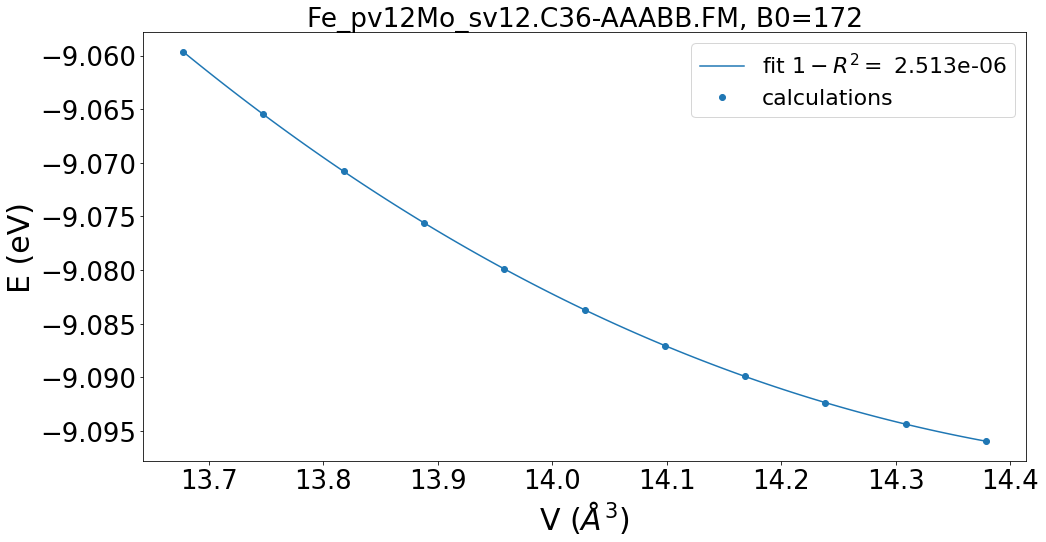

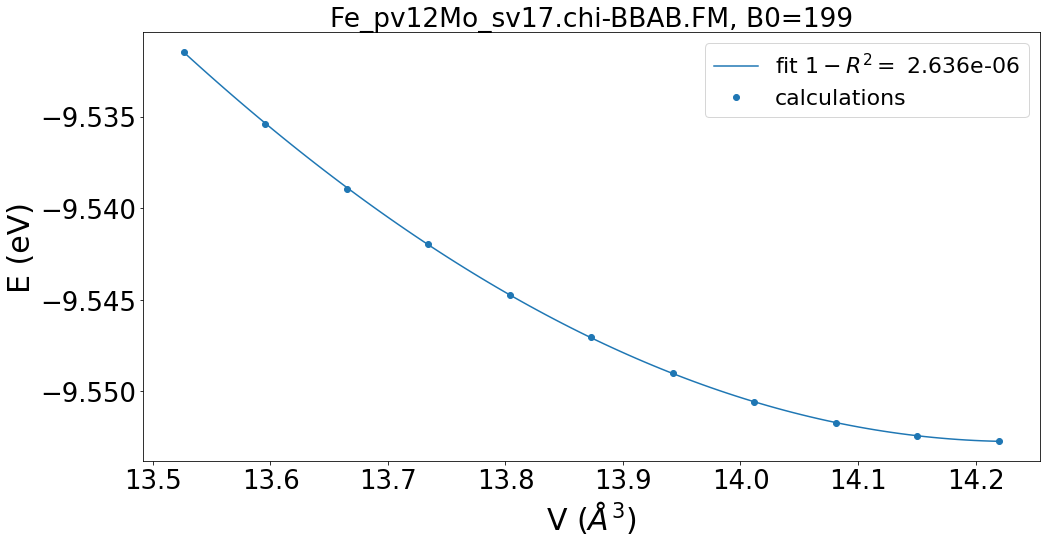

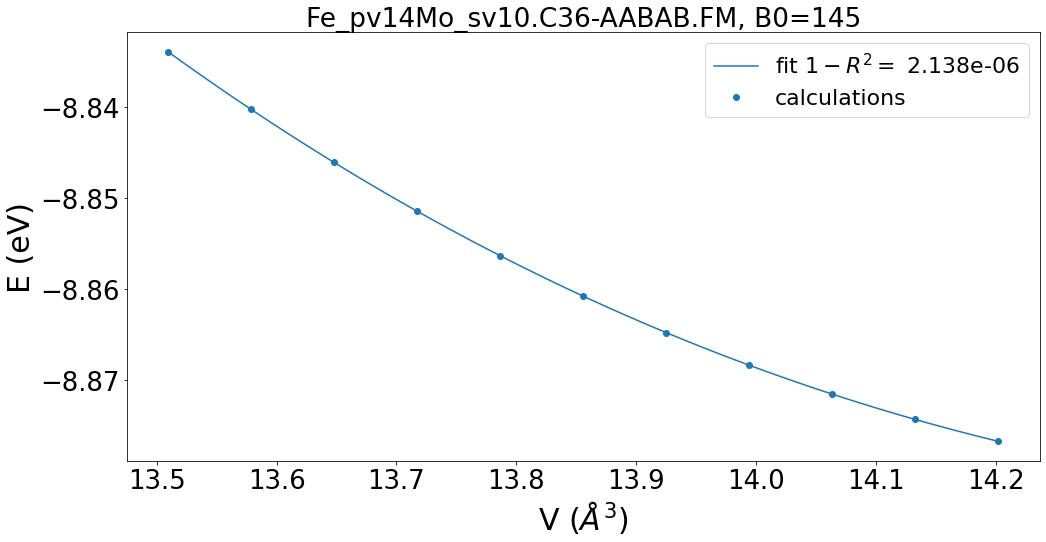

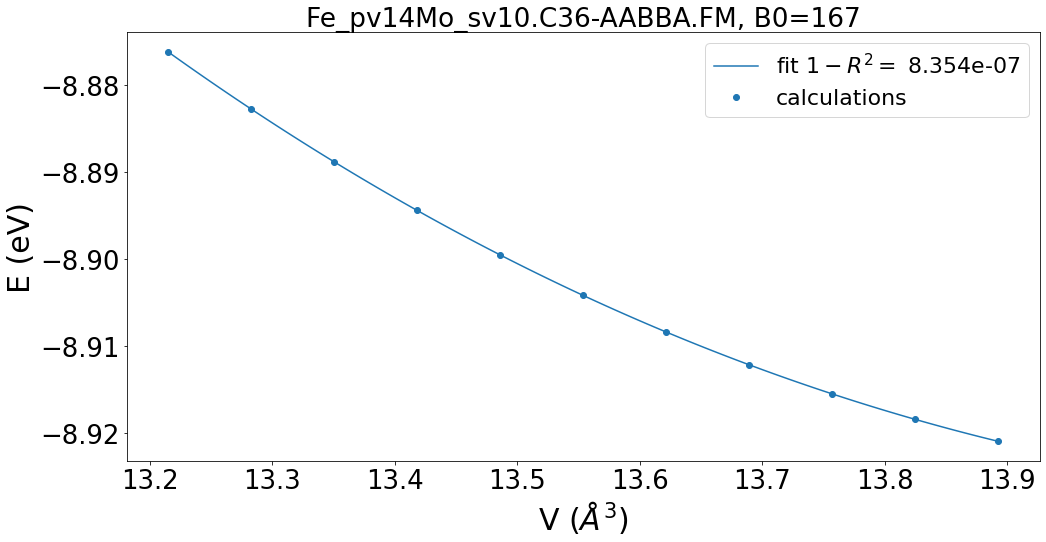

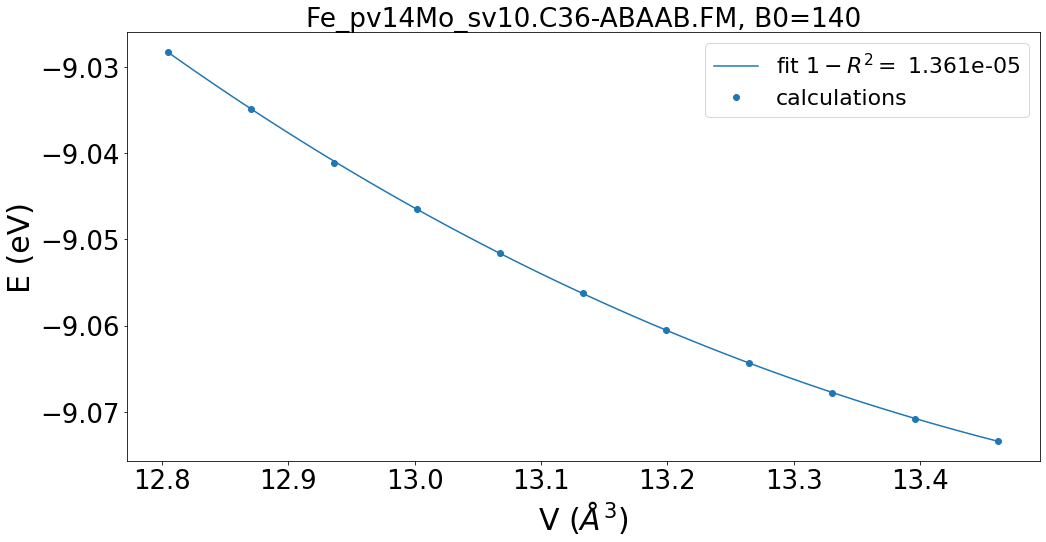

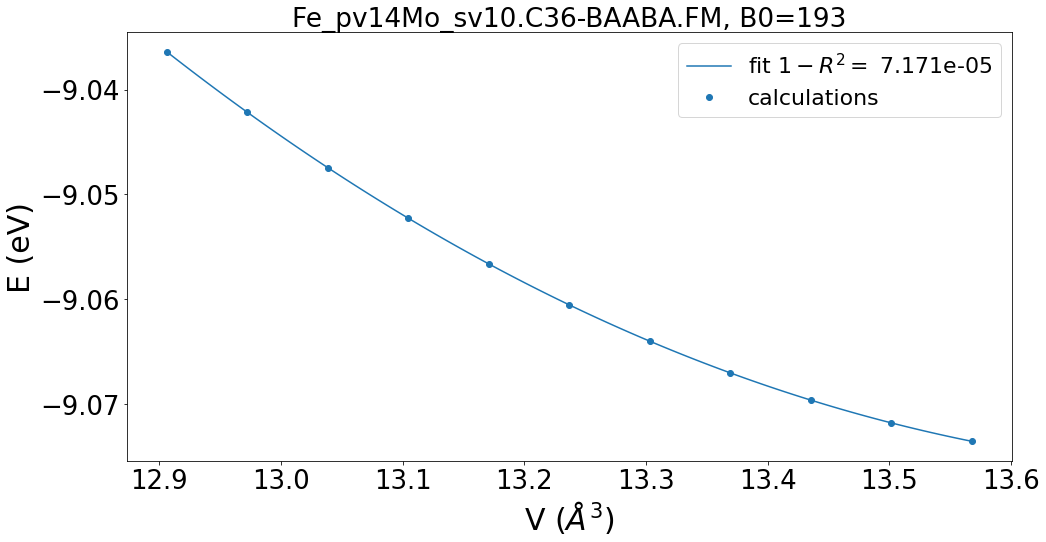

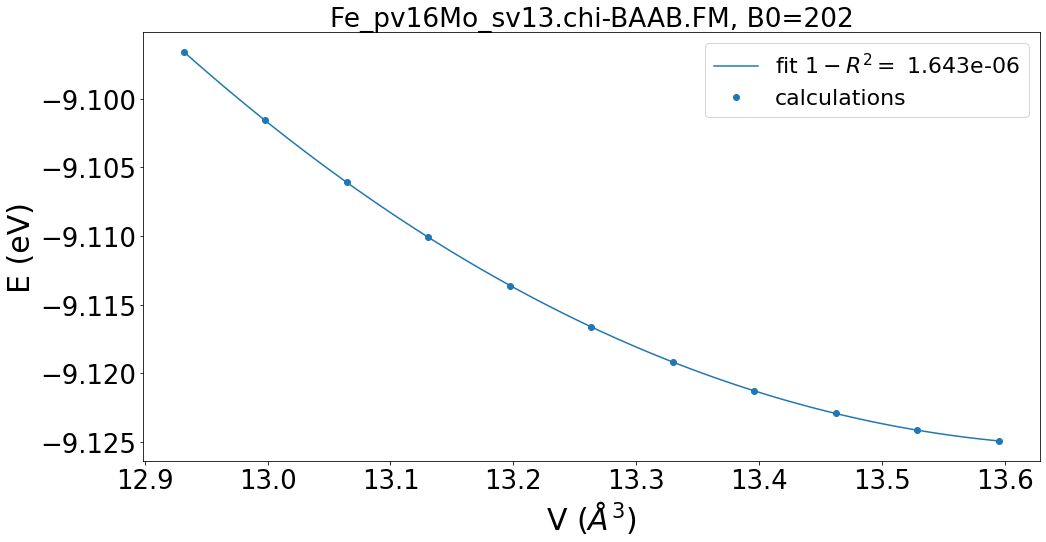

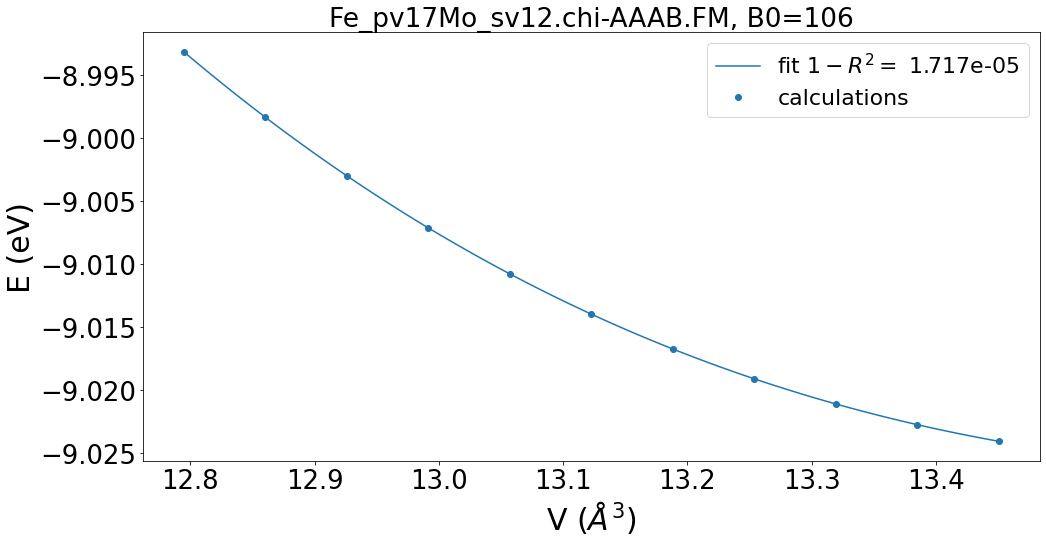

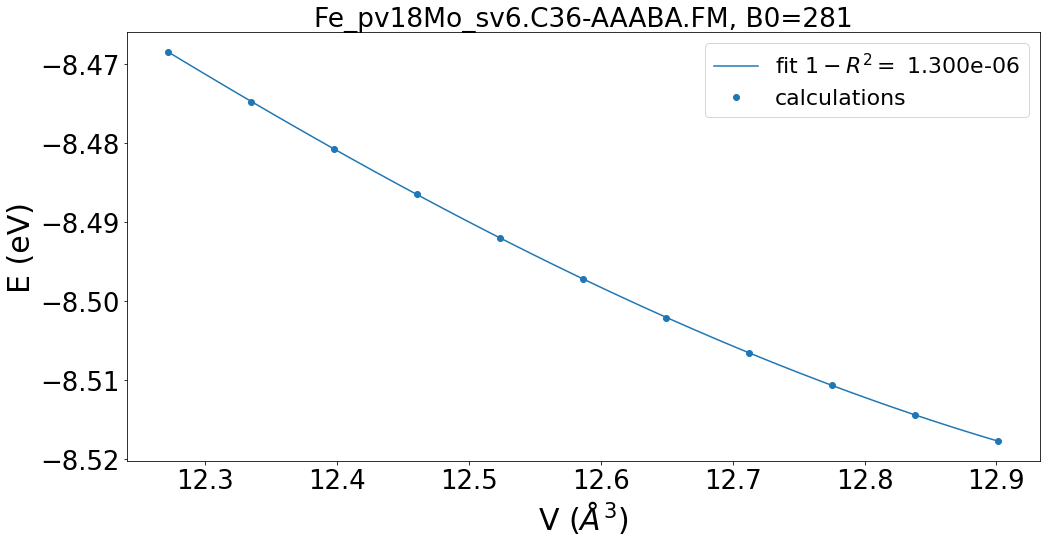

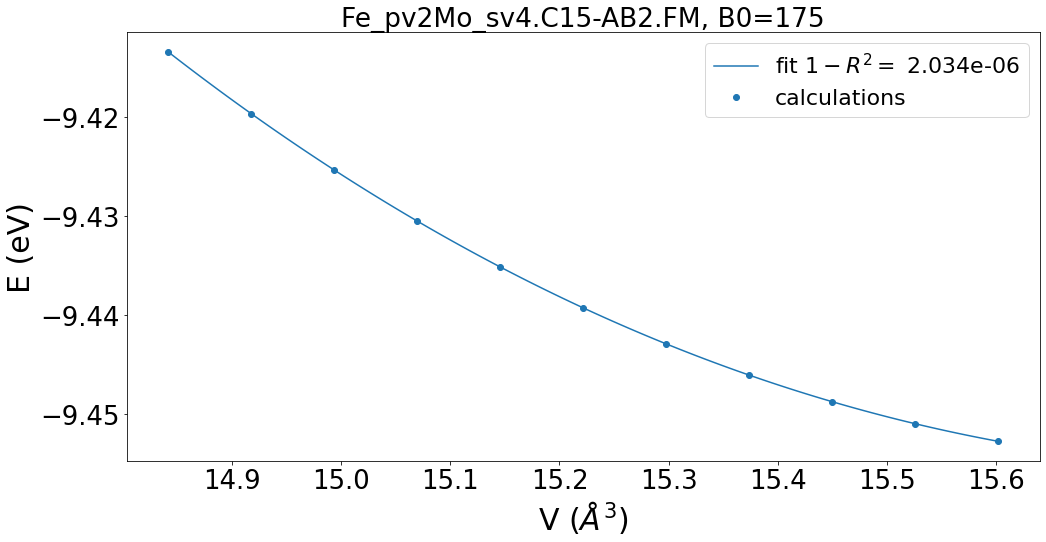

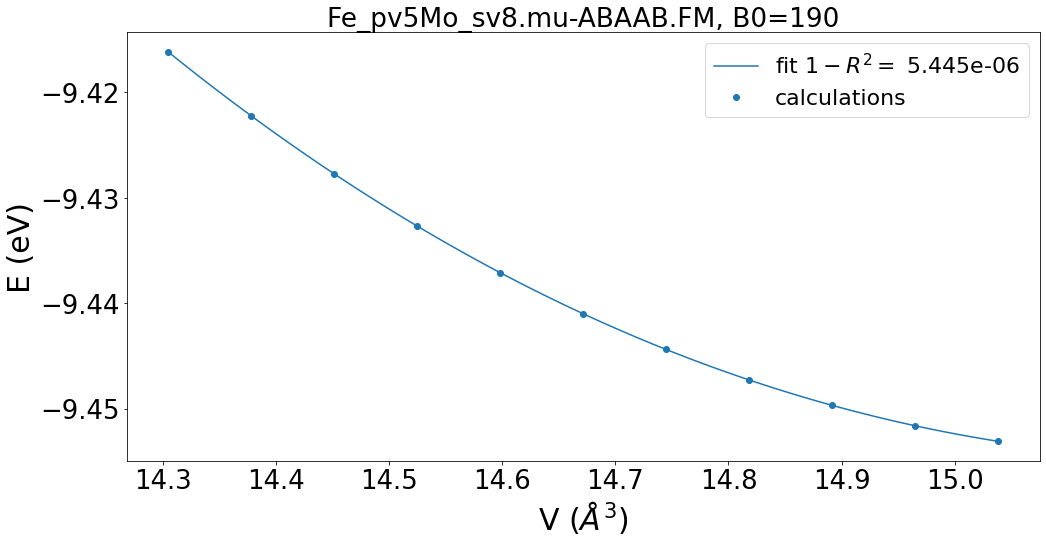

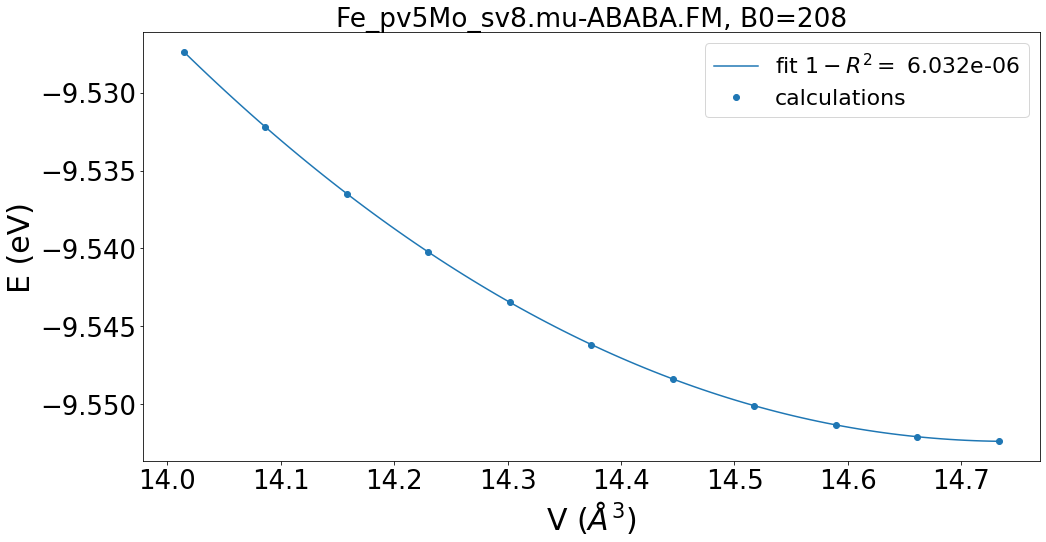

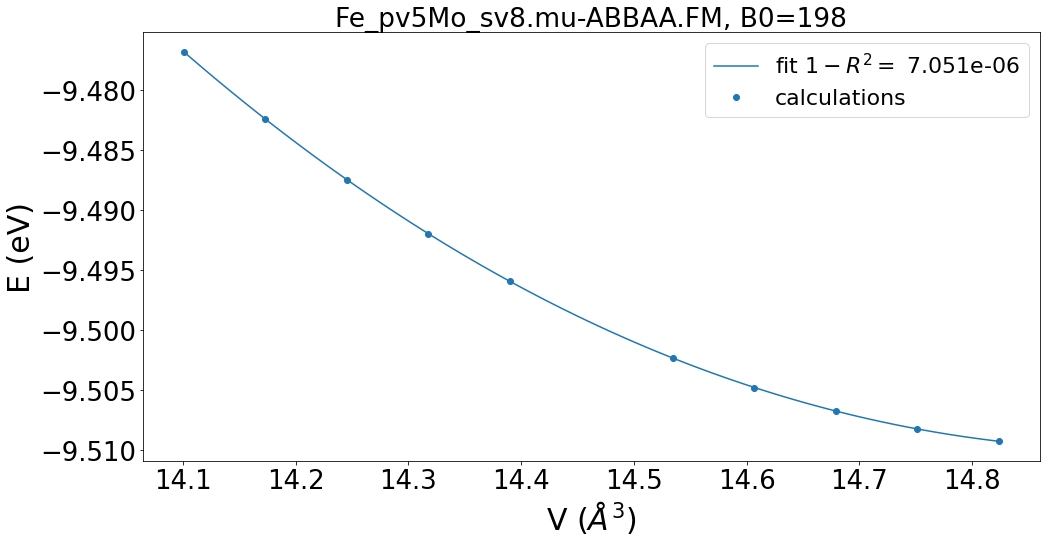

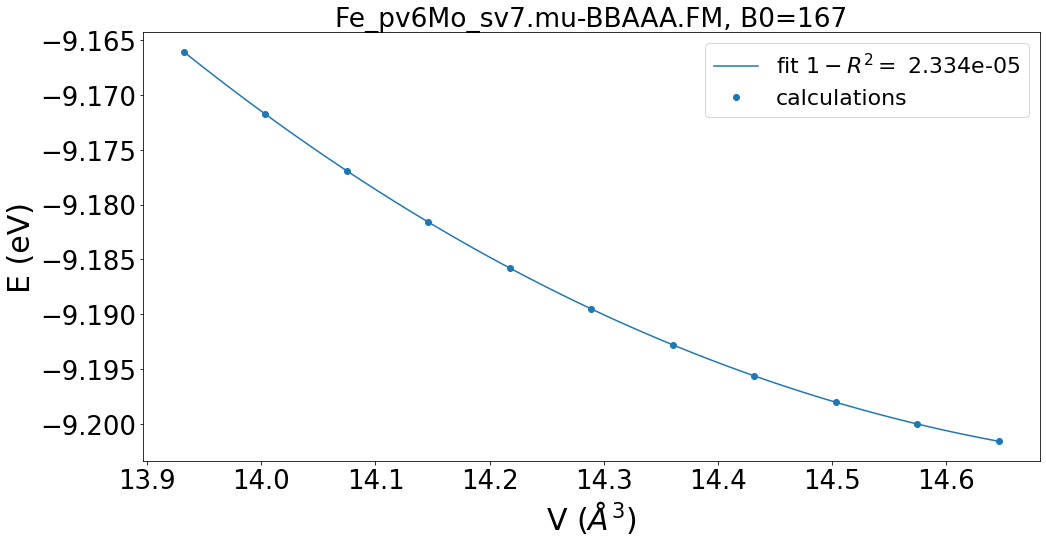

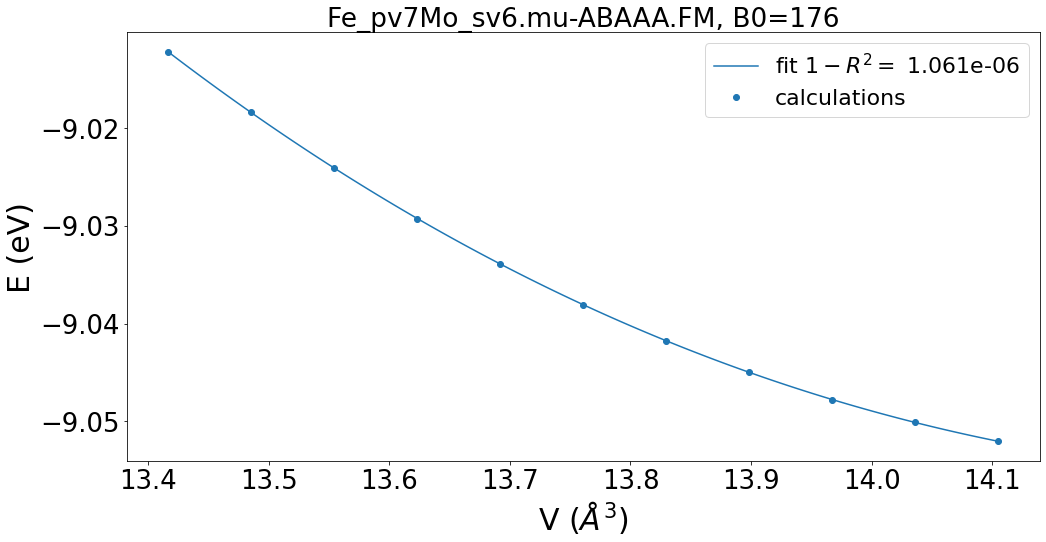

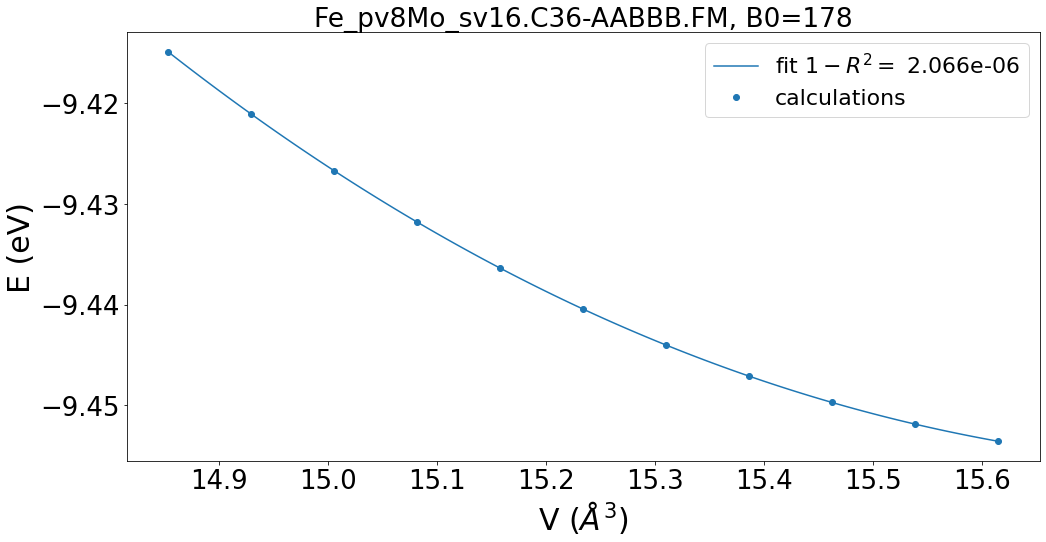

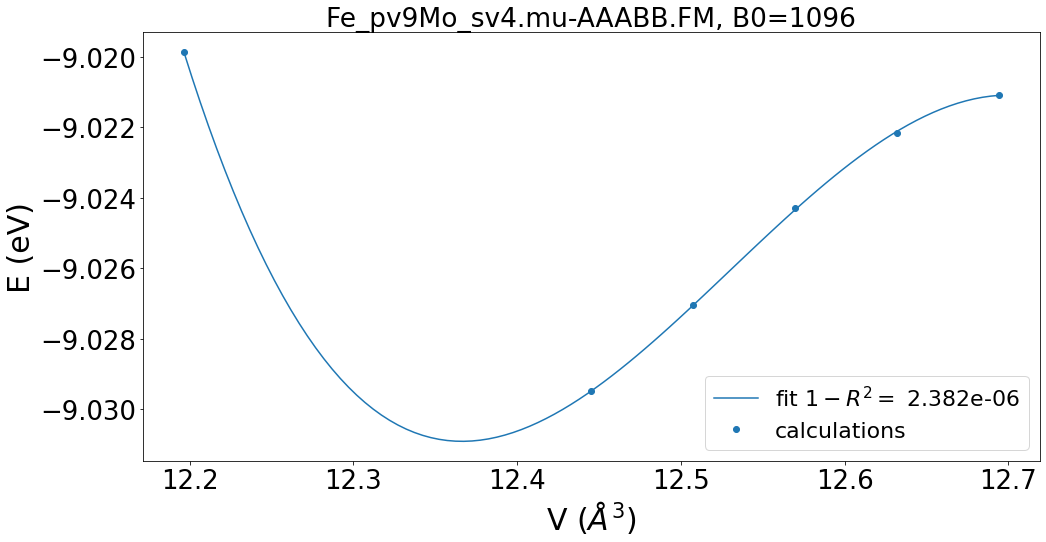

In [161]:
plot_the_sample = SourceFileLoader('plot_the_sample','Tools/DatasetTools/EVCurvesTools.py').load_module().plot_the_sample
plot_curves = SourceFileLoader('plot_curves','Tools/DatasetTools/EVCurvesTools.py').load_module().plot_curves
fig = plot_curves(fixedevcurves[indexoffixedbadsamples], fixedFits[indexoffixedbadsamples], fixedR2[indexofbadsamples])

In [162]:
len(indexoffixedgoodsamples)

233

In [163]:
PBS.shape

(318, 21)

In [164]:
len(indexoffixedgoodsamples) + len(indexofgoodsamples)#+len(indexoffixedbadsamples)

296

In [165]:
indexoffixedgoodsamples[indexoffixedgoodsamples.str.contains('R')]

Index(['Fe_pv27Mo_sv26.R-AAAAAABBBBB.NM', 'Fe_pv27Mo_sv26.R-AAAAABBABBB.NM',
       'Fe_pv27Mo_sv26.R-AAAABABABBB.NM', 'Fe_pv39Mo_sv14.R-AAAABAAAABB.NM',
       'Fe_pv52Mo_sv1.R-BAAAAAAAAAA.NM', 'Fe_pv6Mo_sv47.R-BBBBBBBBBBA.NM',
       'Fe_pv8Mo_sv45.R-BBBBBBBBBAA.NM'],
      dtype='object')

In [166]:
finalindexofsamples = indexofgoodsamples.append(indexoffixedgoodsamples)

In [167]:
finalindexofsamples

Index(['Fe_pv4Mo_sv20.C36-ABBBB.FM', 'Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM',
       'Fe_pv2Mo_sv11.mu-BBABB.FM', 'Fe_pv8Mo_sv22.sigma-BBBAB.NM',
       'Fe_pv2Mo_sv11.mu-BBBBA.NM', 'Fe_pv4Mo_sv20.C36-BBABB.NM',
       'Fe_pv2Mo_sv10.C14-BAB.NM', 'Fe_pv9Mo_sv44.R-AAABBBBBBBB.NM',
       'Fe_pv4Mo_sv26.sigma-BABBB.NM', 'Fe_pv1Mo_sv12.mu-ABBBB.NM',
       ...
       'Fe_pv4Mo_sv2.C15-A2B.FM', 'Fe_pv6Mo_sv2.A15-AB.NM',
       'Fe_pv8Mo_sv16.C36-BAABB.NM', 'Fe_pv30.sigma.FM', 'Fe_pv4.fcc-cubic.FM',
       'Fe_pv6.C15.FM', 'Mo_sv1.bcc.NM', 'Mo_sv8.A15.NM', 'Mo_sv1.fcc.NM',
       'Mo_sv6.C15.NM'],
      dtype='object', length=296)

In [168]:
fixedGoodBS = PBS.loc[finalindexofsamples]

In [169]:
fixedGoodBS.shape

(296, 21)

In [170]:
fixedGoodBS[fixedGoodBS.index.str.contains('R')]

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,V0,atom_A,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,Mag,Phase
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,bulk R-AAAABBBBBBB,14.436090 A,-10.020954,255.953497 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,14.43609,Fe_pv,Mo_sv,15,38,53,0.283019,0.716981,NM,R
Fe_pv9Mo_sv44.R-AAABBBBBBBB.NM,bulk R-AAABBBBBBBB,15.195143 A,-10.255394,247.124292 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,15.195143,Fe_pv,Mo_sv,9,44,53,0.169811,0.830189,NM,R
Fe_pv3Mo_sv50.R-AABBBBBBBBB.NM,bulk R-AABBBBBBBBB,15.948587 A,-10.493489,240.778599 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,15.948587,Fe_pv,Mo_sv,3,50,53,0.056604,0.943396,NM,R
Fe_pv1Mo_sv52.R-ABBBBBBBBBB.NM,bulk R-ABBBBBBBBBB,16.207674 A,-10.574992,238.852230 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,16.207674,Fe_pv,Mo_sv,1,52,53,0.018868,0.981132,NM,R
Mo_sv53.R.NM,bulk R,16.315439 A,-10.625314,238.808096 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,16.315439,Mo_sv,,53,0,53,0.000000,1.000000,NM,R
Mo_sv53.R.FM,bulk R.FM,16.315255 A,-10.625316,238.811481 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,16.315255,Mo_sv,,53,0,53,0.000000,1.000000,FM,R
Fe_pv53.R.NM,bulk R,10.496832 A,-8.018508,274.081057 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,10.496832,Fe_pv,,53,0,53,1.000000,0.000000,NM,R
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM,bulk R-AAAAAAAAABA,10.670060 A,-8.146282,274.796406 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,10.67006,Fe_pv,Mo_sv,51,2,53,0.962264,0.037736,NM,R
Fe_pv50Mo_sv3.R-BBAAAAAAAAA.NM,bulk R-BBAAAAAAAAA,10.804051 A,-8.176541,271.783619 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,10.804051,Fe_pv,Mo_sv,50,3,53,0.943396,0.056604,NM,R
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM,bulk R-AAAAAAAAAAB,11.000617 A,-8.413097,277.323503 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,11.000617,Fe_pv,Mo_sv,47,6,53,0.886792,0.113208,NM,R


# fixed quantities

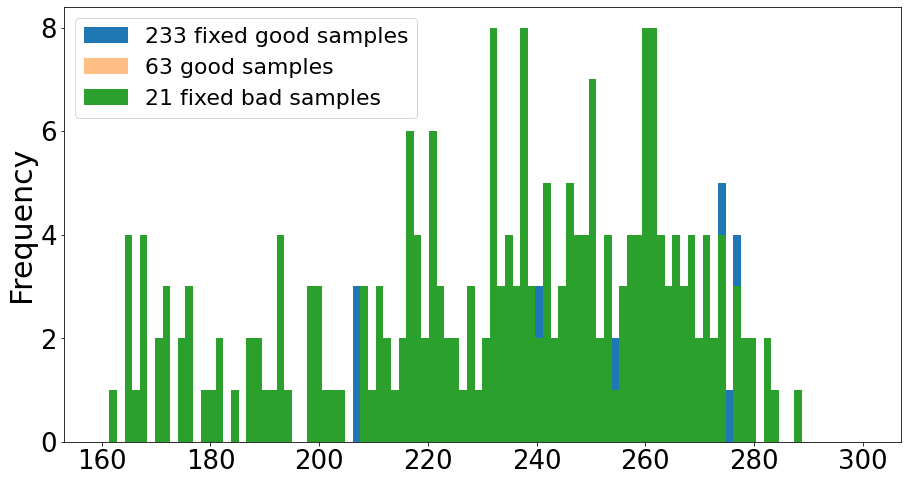

In [171]:
thebins = np.linspace(160, 300, 101)
ax = ev_fit_results_df.B_murn[indexofgoodsamples].plot.hist(bins=thebins)
fixed_ev_fit_results_df.B_murn[indexoffixedgoodsamples].plot.hist(bins=thebins, ax = ax, alpha=0.5, )
fixed_ev_fit_results_df.B_murn[indexoffixedgoodsamples].plot.hist(bins=thebins, ax=ax)
ax.legend([f'{len(indexoffixedgoodsamples)} fixed good samples', f'{len(indexofgoodsamples)} good samples', f'{len(indexoffixedbadsamples)} fixed bad samples'])

# still some bad samples after trying to fix ! 

In [172]:
len(indexoffixedbadsamples)

21

In [173]:
if make_plots:
    for stilbadsample in indexoffixedbadsamples:
        fig, ax=plot_curves(fixedevcurves[[stilbadsample]], fixedFits[[stilbadsample]], fixedR2[[stilbadsample]])
        ax[0].plot(Better_evcurves_df.loc[stilbadsample]['evcurve']['V'],Better_evcurves_df.loc[stilbadsample]['evcurve']['E'] , 'o', markersize=12, markerfacecolor='None')
        handles, labels = ax[0].get_legend_handles_labels()
        thisb0 = fixed_ev_fit_results_df.B_murn[stilbadsample]
        thisbdev = fixed_ev_fit_results_df.Bdev_murn[stilbadsample]
        labels[0] +=f', B0 = {thisb0:.3f}, Bdev = {thisbdev:.3f}'
        ax[0].legend(handles, labels)

# redefine the new good BS

but now I need to correct the E0, B0 and V0 to the results of the fix !

In [174]:
fixedGoodBS['E0'].dropna()

Fe_pv4Mo_sv20.C36-ABBBB.FM        -10.007837
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM   -10.020954
Fe_pv2Mo_sv11.mu-BBABB.FM         -10.117556
Fe_pv8Mo_sv22.sigma-BBBAB.NM      -10.141531
Fe_pv2Mo_sv11.mu-BBBBA.NM          -10.14633
                                     ...    
Fe_pv6.C15.FM                      -8.111077
Mo_sv1.bcc.NM                     -10.932826
Mo_sv8.A15.NM                     -10.837504
Mo_sv1.fcc.NM                     -10.511039
Mo_sv6.C15.NM                      -10.56535
Name: E0, Length: 296, dtype: object

In [175]:
fixedGoodBS['E0'][indexoffixedgoodsamples] = fixed_ev_fit_results_df['E_murn'][indexoffixedgoodsamples]

In [176]:
fixedGoodBS['V0'][indexoffixedgoodsamples] = fixed_ev_fit_results_df['V_murn'][indexoffixedgoodsamples]

In [177]:
fixedGoodBS['B0'][indexoffixedgoodsamples] = fixed_ev_fit_results_df['B_murn'][indexoffixedgoodsamples]

In [178]:
fixedGoodBS.dropna().describe()

,nelem,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv
count,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000
mean,1.841216,12.966216,10.175676,23.141892,0.504617,0.495383
std,0.366093,10.842112,9.528701,13.715764,0.295248,0.295248
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000
25%,2.000000,4.750000,2.000000,13.000000,0.266667,0.264151
50%,2.000000,10.000000,8.000000,24.000000,0.500000,0.500000
75%,2.000000,18.000000,16.000000,30.000000,0.735849,0.733333
max,2.000000,53.000000,52.000000,53.000000,1.000000,1.000000


In [179]:
fixedGoodBS.shape

(296, 21)

## Remove extra magnetic sampling

First feature to remove from this dataset is the list of samples used form ferrimagnetic phase sampling. This subset is not in the current interest and might bring problems so we remove from datastet.

In [180]:
fixedGoodBS.query('index.str.contains("[UD]+$")')#.loc[['Fe_pv30.sigma.FM', 'Fe_pv30.sigma.NM']]

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,V0,atom_A,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,Mag,Phase


## Obtain some info from indexes

In [181]:
Features = Featurizer(fixedGoodBS)

In [182]:
fixedGoodBS.shape

(296, 21)

# TODo this sould be in tools, as a phase cleaner

In [183]:
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.struct_db import struct_db
#struct_db = SourceFileLoader('struct_db','BopFoxFeaturizer/struct_db.py').load_module().struct_db
strucdic = struct_db().strucstrings

Target_Class = pd.Series(
    fixedGoodBS.index.str.split('.').map(lambda l: l[1]).map(lambda s: s.split('-')[0]),
    index=fixedGoodBS.index
)
Target_Class[Target_Class.map(lambda s: s in strucdic['list.hcp'])]='hcp'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.fcc'])]='fcc'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.bcc'])]='bcc'
Target_Class[Features.Struc == 'hcp'] = 'hcp'
Target_Class[Features.Struc == 'bcc'] = 'bcc'
Target_Class[Features.Struc == 'fcc'] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-fcc')] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-L12')] = 'fcc'
Target_Class[Features.Struc.str.contains('sigma_')] = 'sigma'

Target_Class[    
    Target_Class.str.contains('Al42W') |\
    Target_Class.str.contains('Al9Co2') |\
    Target_Class.str.contains('Al5W') |\
    Target_Class.str.contains('Al12W') |\
    Target_Class.str.contains('Al4W') |\
    Target_Class.str.contains('Al5Co2')
] = 'others'

In [184]:
DescriptorsLoc = os.path.join(dataset,'Descriptors')
if not os.path.exists(DescriptorsLoc):
    os.makedirs(DescriptorsLoc)
Target_Class.to_pickle(os.path.join(DescriptorsLoc, 'ClassLabels.pkl'))

In [185]:
fixedGoodBS['Phase'] = Target_Class

In [186]:
fixedGoodBS.describe()

,nelem,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv
count,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000
mean,1.841216,12.966216,10.175676,23.141892,0.504617,0.495383
std,0.366093,10.842112,9.528701,13.715764,0.295248,0.295248
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000
25%,2.000000,4.750000,2.000000,13.000000,0.266667,0.264151
50%,2.000000,10.000000,8.000000,24.000000,0.500000,0.500000
75%,2.000000,18.000000,16.000000,30.000000,0.735849,0.733333
max,2.000000,53.000000,52.000000,53.000000,1.000000,1.000000


# force magnetic R out

In [191]:
fmr = fixedGoodBS.query('Phase == "R" and Mag == "FM"').index

In [193]:
fixedGoodBS.drop(fmr, inplace=True)

# Save good fixed BS 

In [195]:
fixedGoodBS.to_pickle(os.path.join(dataset, "CuratedParsedBriefSummary.pkl") )

# some E-V curves, good and bad

## sample bad

In [196]:
sample_bad_index = BadBS.sample(n=5).index#.append(pd.Index(['Mo_sv53.R.NM'])).unique()

In [197]:
sample_bad = EVcurves[sample_bad_index] #[BadBS.index].dropna().sample(n=min(5, BadBS.shape[0]))

In [198]:
plt.rc('font', size=22)
plt.rc('figure', figsize=(12,8))

In [199]:
sample_bad_r2 = R2[sample_bad.index]

In [93]:
sample_bad_fit = Fits[sample_bad.index]

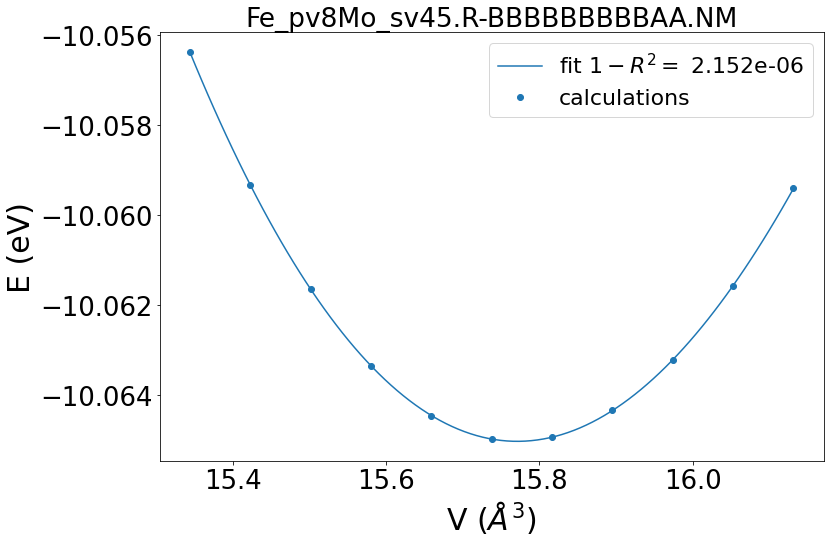

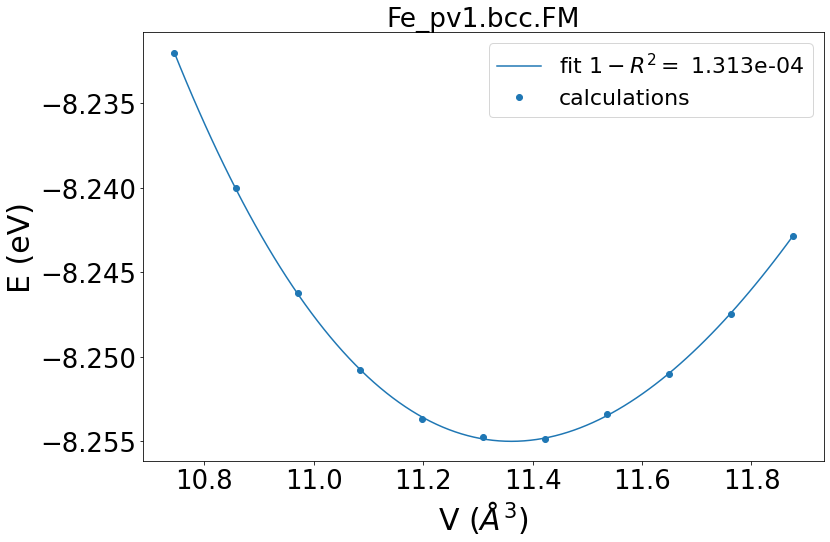

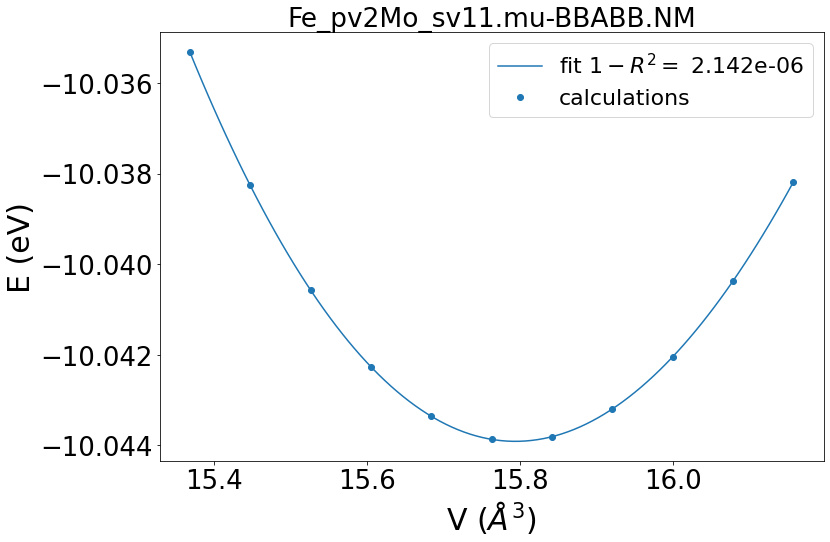

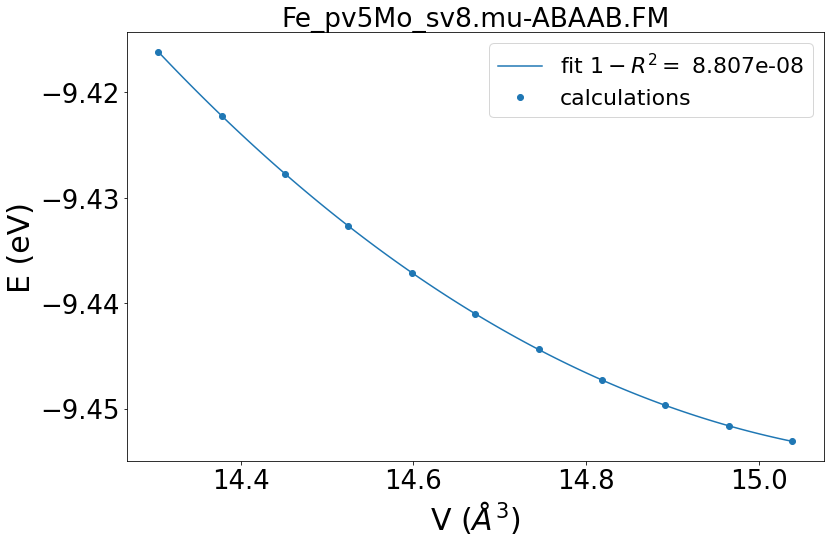

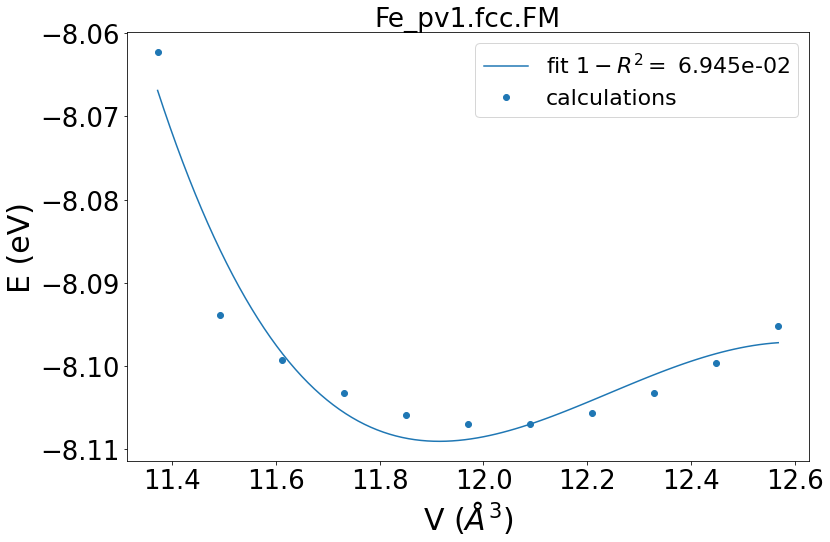

In [94]:
figurecollection, axcollection  = plot_curves(sample_bad, sample_bad_fit, sample_bad_r2)

# Cases of interest

In [95]:
interesting_cases = ['Fe_pv28Mo_sv1.chi-BAAA.FM', 'Fe_pv11Mo_sv2.mu-AAABA.FM', 'Fe_pv1.fcc.FM', 'Fe_pv1.fcc.FM', Mo_R]

In [96]:
Better_evcurves_df.IsGood[interesting_cases]

Fe_pv28Mo_sv1.chi-BAAA.FM    False
Fe_pv11Mo_sv2.mu-AAABA.FM    False
Fe_pv1.fcc.FM                False
Fe_pv1.fcc.FM                False
Mo_sv53.R.NM                  True
Name: IsGood, dtype: bool

In [97]:
Fits.loc[interesting_cases][0]

{'xc=PBE-PAW.E=450.dk=0.020': array([-8.23994851e+00,  7.97575010e-01,  5.13504221e+03,  1.15394111e+01])}

In [98]:
Better_evcurves_df.ev_fit_results[interesting_cases][0]

{'E_murn': -8.240007,
 'V_murn': 11.555812,
 'B_murn': 20.484025,
 'Bdev_murn': 59.173261}

In [191]:
#figs, axs = plot_curves(EVcurves[interesting_cases], Fits[interesting_cases], R2[interesting_cases])


# Sample good

In [100]:
sample_good = EVcurves[fixedGoodBS.index].dropna().sample(n=5)

In [101]:
sample_good

Fe_pv22Mo_sv8.sigma-AAAAB.FM      {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv4Mo_sv20.C36-BBABB.FM        {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv52Mo_sv1.R-BAAAAAAAAAA.NM    {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv2Mo_sv6.D0_19-AB3.FM         {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv3Mo_sv10.mu-ABABB.FM         {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
dtype: object

In [102]:
sample_good_r2 = R2[sample_good.index]

In [103]:
sample_good_fit = Fits[sample_good.index]

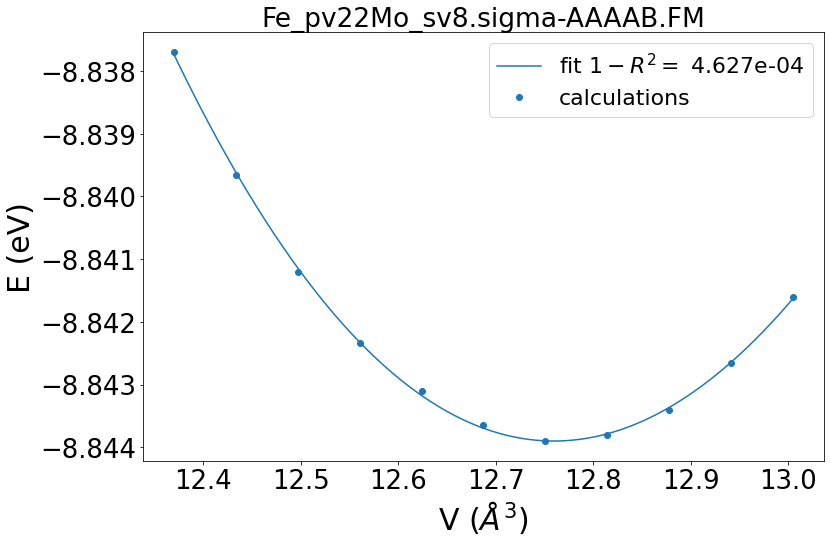

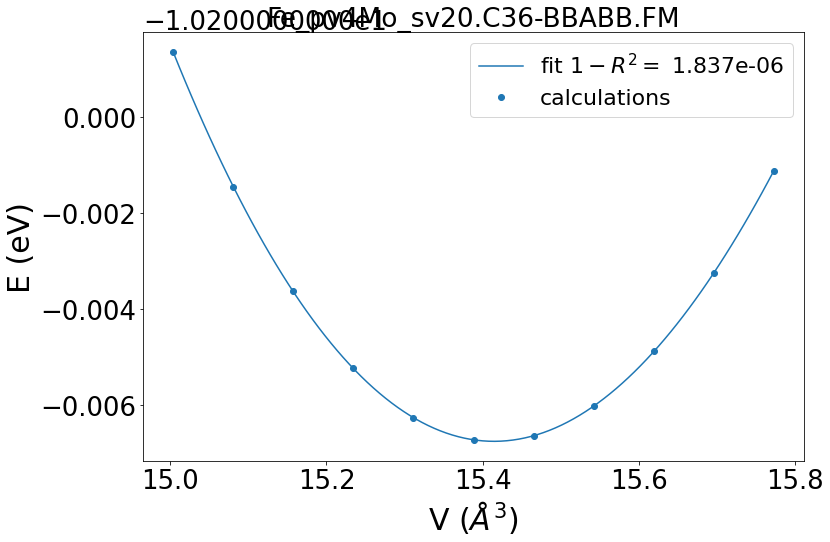

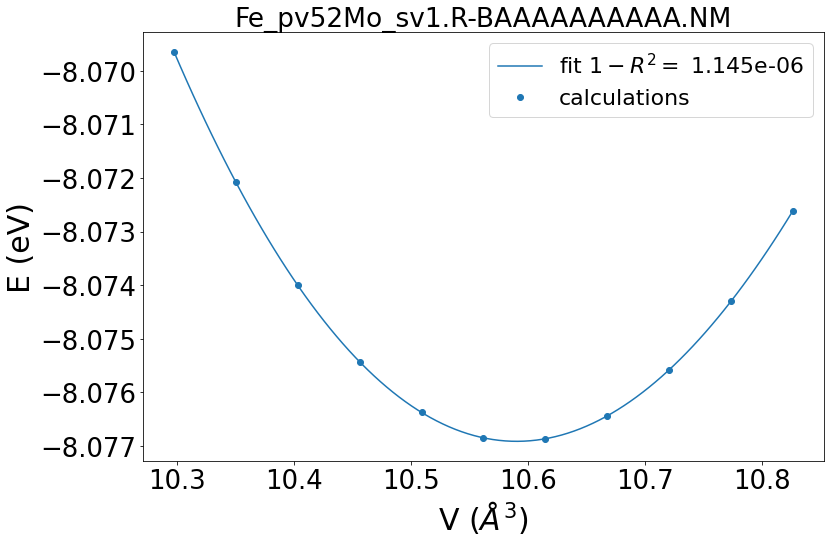

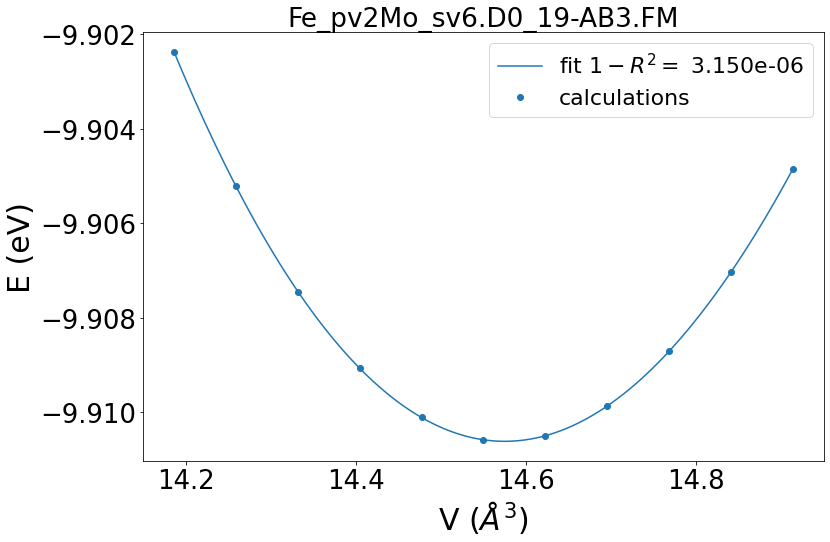

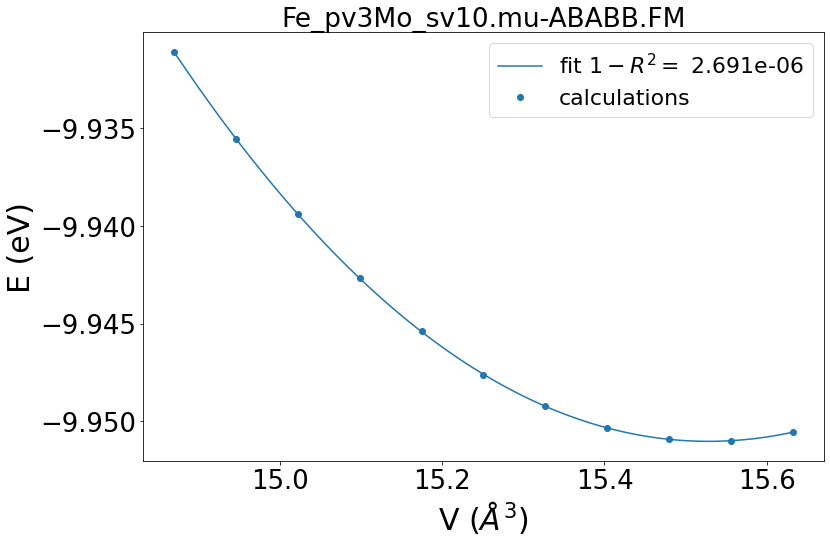

In [104]:
figurecollection, axcollection  = plot_curves(sample_good, sample_good_fit, sample_good_r2)

In [105]:
sample_max_B0 = fixedGoodBS.query('nelem == 1').B0.idxmax()

In [106]:
sample_min_B0 = fixedGoodBS.query('nelem == 1').B0.idxmin()

In [107]:
fixedGoodBS.B0[[sample_min_B0]]

Fe_pv29.chi.FM    141.243922
Name: B0, dtype: float64

In [108]:
fixedGoodBS.B0[[sample_max_B0]]

Fe_pv2.hcp.NM    287.828951
Name: B0, dtype: float64

In [109]:
theminbo = EVcurves_df.loc[sample_min_B0].dropna()

In [110]:
theminbo[0]

{'evcurve': {'V': array([12.20209483, 12.14257241, 12.08305   , 12.02352759, 11.96400517,
         11.90448276, 11.84496034, 11.78543793, 11.72591552, 11.6663931 ,
         11.60687069]),
  'E': array([-8.13550931, -8.13647862, -8.13713379, -8.13749276, -8.13550069,
         -8.13721655, -8.13661655, -8.13563345, -8.13467793, -8.13458207,
         -8.13454448])},
 'ev_fit_results': {'E_murn': -8.137048,
  'V_murn': 12.050793,
  'B_murn': 152.259441,
  'Bdev_murn': -117.055042},
 'r2': 0.7439803024901831,
 'fit': array([ -8.13707309, 151.41578785, -49.39795564,  12.02569393]),
 'IsGood': False,
 'calc_param': 'xc=PBE-PAW.E=450.dk=0.020'}

In [111]:
selection = ((fixedGoodBS.B0>=fixedGoodBS.B0[sample_min_B0]) & (fixedGoodBS.B0<=fixedGoodBS.B0[sample_max_B0]))

In [112]:
selection.sum()

292

In [113]:
selection_stricter = ((fixedGoodBS.B0>1.1*fixedGoodBS.B0[sample_min_B0]) & (fixedGoodBS.B0<0.90*fixedGoodBS.B0[sample_max_B0]) &
                     (list(R2[sample_max_B0].values())[0] > 0.998))

In [114]:
selection_stricter

Fe_pv4Mo_sv20.C36-ABBBB.FM          True
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM     True
Fe_pv2Mo_sv11.mu-BBABB.FM           True
Fe_pv8Mo_sv22.sigma-BBBAB.NM       False
Fe_pv2Mo_sv11.mu-BBBBA.NM           True
                                   ...  
Fe_pv6.C15.FM                      False
Mo_sv1.bcc.NM                       True
Mo_sv8.A15.NM                       True
Mo_sv1.fcc.NM                       True
Mo_sv6.C15.NM                       True
Name: B0, Length: 292, dtype: bool

In [115]:
samples_wrong_b0 = fixedGoodBS[~selection].index

In [116]:
len(samples_wrong_b0)

0

<AxesSubplot:ylabel='Frequency'>

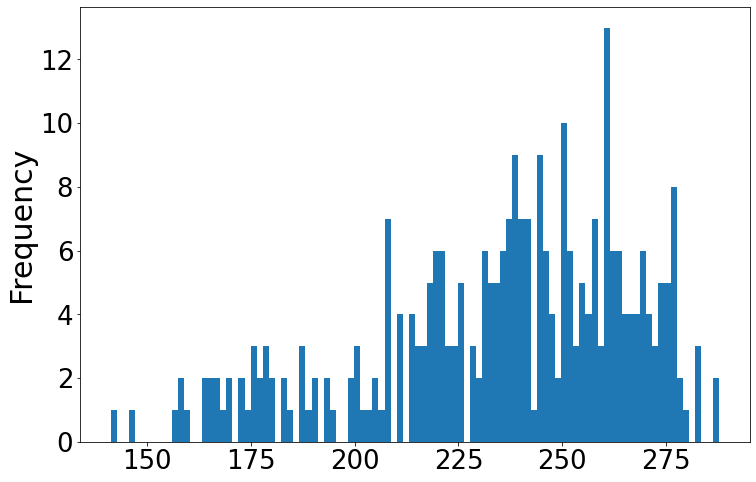

In [117]:
fixedGoodBS.B0.plot.hist(bins=100)

In [118]:
curve_wrong_b0 = EVcurves[samples_wrong_b0]

In [119]:
r2_wrong_b0 = R2[samples_wrong_b0]

In [120]:
fits_wrong_b0 = Fits[samples_wrong_b0]

In [121]:
curve_wrong_b0

Series([], dtype: object)

In [122]:
figurecollection, axcollection  = plot_curves(curve_wrong_b0, fits_wrong_b0, r2_wrong_b0)
for ax, index  in zip(axcollection, samples_wrong_b0):
    title=ax.get_title()
    title += f'$B_0$ = {fixedGoodBS.B0[index]}'
    ax.set_title(title)

In [123]:
GoodBS.drop(index=samples_wrong_b0, inplace=True)

In [124]:
samples_low_b0 = GoodBS.query('B0 < 150').index

In [125]:
curve_low_b0 = EVcurves[samples_low_b0]

In [126]:
r2_low_b0 = R2[samples_low_b0]

In [127]:
fits_low_b0 = Fits[samples_low_b0]

In [128]:
figurecollection, axcollection  = plot_curves(curve_low_b0, fits_low_b0, r2_low_b0)
for ax, index  in zip(axcollection, samples_low_b0):
    title=ax.get_title()
    title += f'$B_0$ = {GoodBS.B0[index]}'
    ax.set_title(title)

# Save for later use 

In [129]:
#curatedbs = os.path.join(dataset,'CuratedParsedBriefSummary.pkl')
#GoodBS.to_pickle(curatedbs)

<AxesSubplot:>

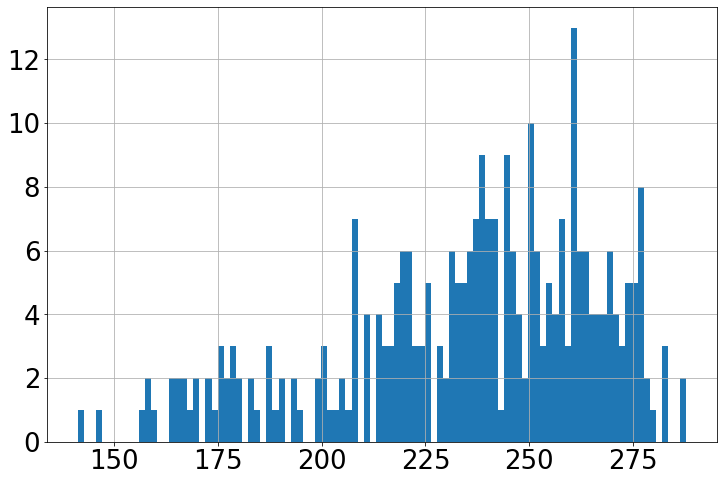

In [130]:
fixedGoodBS.B0.hist(bins=100)

# a bit of a different formulation

In [ ]:
PBS['config'] = PBS.index.str.split('.').map(lambda a: a[1].split('-')[-1])

In [ ]:
PBS['system'] = PBS.index.map(lambda a: '-'.join(re.findall('Fe|Mo', a)))

In [ ]:
PBS.index = pd.MultiIndex.from_frame(PBS[['system', 'Phase', 'config', 'Mag']])

In [ ]:
PBS.set_index(['system', 'Phase', 'config', 'Mag'], inplace=True)

In [ ]:
PBS

V         E0  \
system Phase config Mag                                                  
Fe-Mo  sigma BBABB  FM   bulk  sigma-BBABB.FM  14.954763 A  -10.004507   
             ABBAB  FM   bulk  sigma-ABBAB.FM  14.130625 A  -10.006896   
       C36   ABBBB  FM     bulk  C36-ABBBB.FM  16.270923 A  -10.007837   
       mu    ABBBA  FM      bulk  mu-ABBBA.FM  15.378254 A  -10.008565   
       chi   AABB   FM      bulk  chi-AABB.FM  15.751001 A   -10.01501   
...                                       ...           ...        ...   
       mu    ABBBA  NM         bulk  mu-ABBBA  15.125643 A   -9.973264   
       sigma BBABB  NM      bulk  sigma-BBABB  14.698886 A   -9.976143   
       fcc   AB3    FM       bulk  L12-AB3.FM  14.806728 A   -9.986411   
       sigma BBBBA  FM   bulk  sigma-BBBBA.FM  15.095159 A    -9.99108   
             ABBAB  NM      bulk  sigma-ABBAB  14.000772 A   -9.993055   

                                       B                         fit       xc  \
system Phase config Mag                                                         
Fe-Mo  sigma BBABB  FM   224.285410 GPa   murnaghan  volume_relaxed   PBE-PAW   
             ABBAB  FM   237.907324 GPa   murnaghan  volume_relaxed   PBE-PAW   
       C36   ABBBB  FM   204.470374 GPa   murnaghan  volume_relaxed   PBE-PAW   
       mu    ABBBA  FM   402.123952 GPa   murnaghan  volume_relaxed   PBE-PAW   
       chi   AABB   FM   216.183583 GPa   murnaghan  volume_relaxed   PBE-PAW   
...                                  ...                         ...      ...   
       mu    ABBBA  NM   240.020984 GPa   murnaghan  volume_relaxed   PBE-PAW   
       sigma BBABB  NM   247.238692 GPa   murnaghan  volume_relaxed   PBE-PAW   
       fcc   AB3    FM   223.435464 GPa   murnaghan  volume_relaxed   PBE-PAW   
       sigma BBBBA  FM   207.683558 GPa   murnaghan  volume_relaxed   PBE-PAW   
             ABBAB  NM   263.965297 GPa   murnaghan  volume_relaxed   PBE-PAW   

                        encut deltak ncrash  nelem          B0         V0  \
system Phase config Mag                                                     
Fe-Mo  sigma BBABB  FM    450  0.020      0      2   224.28541  14.954763   
             ABBAB  FM    450  0.020      0      2  237.907324  14.130625   
       C36   ABBBB  FM    450  0.020      0      2  204.470374  16.270923   
       mu    ABBBA  FM    450  0.020      0      2  402.123952  15.378254   
       chi   AABB   FM    450  0.020      0      2  216.183583  15.751001   
...                       ...    ...    ...    ...         ...        ...   
       mu    ABBBA  NM    450  0.020      0      2  240.020984  15.125643   
       sigma BBABB  NM    450  0.020      0      2  247.238692  14.698886   
       fcc   AB3    FM    450  0.020      0      2  223.435464  14.806728   
       sigma BBBBA  FM    450  0.020      0      2  207.683558  15.095159   
             ABBAB  NM    450  0.020      0      2  263.965297  14.000772   

                        atom_A atom_B  num_atom_A  num_atom_B  num_atoms  \
system Phase config Mag                                                    
Fe-Mo  sigma BBABB  FM   Fe_pv  Mo_sv           8          22         30   
             ABBAB  FM   Fe_pv  Mo_sv          10          20         30   
       C36   ABBBB  FM   Fe_pv  Mo_sv           4          20         24   
       mu    ABBBA  FM   Fe_pv  Mo_sv           3          10         13   
       chi   AABB   FM   Fe_pv  Mo_sv           5          24         29   
...                        ...    ...         ...         ...        ...   
       mu    ABBBA  NM   Fe_pv  Mo_sv           3          10         13   
       sigma BBABB  NM   Fe_pv  Mo_sv           8          22         30   
       fcc   AB3    FM   Fe_pv  Mo_sv           1           3          4   
       sigma BBBBA  FM   Fe_pv  Mo_sv           8          22         30   
             ABBAB  NM   Fe_pv  Mo_sv          10          20         30   

                            Fe_pv     Mo_sv  
syst